# Jester Dataset: Exploratory Data Analysis
### Personalized Joke Recommendation System

**Dataset:** Jester Dataset 1 (UC Berkeley, Eigentaste Project)  
**Source:** https://eigentaste.berkeley.edu/dataset/
**Contents:** ~73,421 users × 100 jokes, continuous ratings from −10 to +10 (99 = not rated)

### In this Notebook 
1. Environment Setup & Imports  
2. Data Loading & Initial Inspection  
3. Missing Value Analysis  
4. Rating Distribution Analysis  
5. User Activity Analysis  
6. Joke Popularity Analysis  
7. Sparsity Visualization  
8. Correlation & Similarity Analysis  
9. User Segmentation (Clustering)  
10. Content Analysis (Joke Texts)  
11. Key EDA Summary & Observations

## 1. Environment Setup & Imports

In [4]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import skew, kurtosis

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ── NLP (for joke text analysis) ─────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import re

# ── Misc ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.figsize': (12, 5)
})

SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


## 2. Data Loading & Initial Inspection

In [5]:
# ── Load the raw Excel file ───────────────────────────────────────────────────
# Download jester-data-1-new.xls from https://eigentaste.berkeley.edu/dataset/
# Place it in the same directory as this notebook.

RAW_PATH = '../Data/jester-data-1.xls'

raw = pd.read_excel(RAW_PATH, header=None)
print(f'Raw shape: {raw.shape}')      # Expected: (73421, 101)

# Column 0 = number of jokes rated by each user (keep separately)
n_jokes_rated = raw.iloc[:, 0].copy()
ratings_raw   = raw.iloc[:, 1:].copy()     # 73421 rows × 100 cols

# Rename columns to joke_1 … joke_100
ratings_raw.columns = [f'joke_{i}' for i in range(1, 101)]
ratings_raw.index.name = 'user_id'

print(f'Ratings matrix shape: {ratings_raw.shape}')
print(f'\nFirst 5 rows (raw — 99 means not rated):')
ratings_raw.head()

Raw shape: (24983, 101)
Ratings matrix shape: (24983, 100)

First 5 rows (raw — 99 means not rated):


,joke_1,joke_2,joke_3,joke_4,joke_5,joke_6,joke_7,joke_8,joke_9,joke_10,...,joke_91,joke_92,joke_93,joke_94,joke_95,joke_96,joke_97,joke_98,joke_99,joke_100
user_id,,,,,,,,,,,,,,,,,,,,,
0,-7.82,8.79,-9.66,-8.16,-7.52,-8.50,-9.85,4.17,-8.98,-4.76,...,2.82,99.00,99.00,99.00,99.00,99.00,-5.63,99.00,99.00,99.00
1,4.08,-0.29,6.36,4.37,-2.38,-9.66,-0.73,-5.34,8.88,9.22,...,2.82,-4.95,-0.29,7.86,-0.19,-2.14,3.06,0.34,-4.32,1.07
2,99.00,99.00,99.00,99.00,9.03,9.27,9.03,9.27,99.00,99.00,...,99.00,99.00,99.00,9.08,99.00,99.00,99.00,99.00,99.00,99.00
3,99.00,8.35,99.00,99.00,1.80,8.16,-2.82,6.21,99.00,1.84,...,99.00,99.00,99.00,0.53,99.00,99.00,99.00,99.00,99.00,99.00
4,8.50,4.61,-4.17,-5.39,1.36,1.60,7.04,4.61,-0.44,5.73,...,5.19,5.58,4.27,5.19,5.73,1.55,3.11,6.55,1.80,1.60


In [6]:
# ── Replace sentinel value 99 → NaN ──────────────────────────────────────────
# The Jester dataset uses 99 as a placeholder for "not rated".
# This MUST be replaced before any analysis or modelling.

ratings = ratings_raw.replace(99, np.nan)

print('Value counts for sentinel (99) before replacement:')
print(f'  Cells equal to 99: {(ratings_raw == 99).sum().sum():,}')
print(f'  NaN cells after replacement: {ratings.isnull().sum().sum():,}')
print(f'\nValue range of known ratings: [{ratings.min().min():.2f}, {ratings.max().max():.2f}]')

Value counts for sentinel (99) before replacement:
  Cells equal to 99: 687,845
  NaN cells after replacement: 687,845

Value range of known ratings: [-9.95, 10.00]


In [7]:
# ── Dataset summary statistics ────────────────────────────────────────────────
total_cells   = ratings.size
known_ratings = ratings.notna().sum().sum()
missing       = ratings.isna().sum().sum()
sparsity      = missing / total_cells
density       = known_ratings / total_cells

print('=' * 55)
print('JESTER DATASET — OVERVIEW')
print('=' * 55)
print(f'  Users             : {ratings.shape[0]:>10,}')
print(f'  Jokes             : {ratings.shape[1]:>10,}')
print(f'  Total cells       : {total_cells:>10,}')
print(f'  Known ratings     : {known_ratings:>10,}')
print(f'  Missing (not rated): {missing:>9,}')
print(f'  Sparsity          : {sparsity:>9.1%}')
print(f'  Density           : {density:>9.1%}')
print(f'  Rating scale      :   [-10, +10]')
print('=' * 55)

JESTER DATASET — OVERVIEW
  Users             :     24,983
  Jokes             :        100
  Total cells       :  2,498,300
  Known ratings     :  1,810,455
  Missing (not rated):   687,845
  Sparsity          :     27.5%
  Density           :     72.5%
  Rating scale      :   [-10, +10]


## 3. Missing Value Analysis

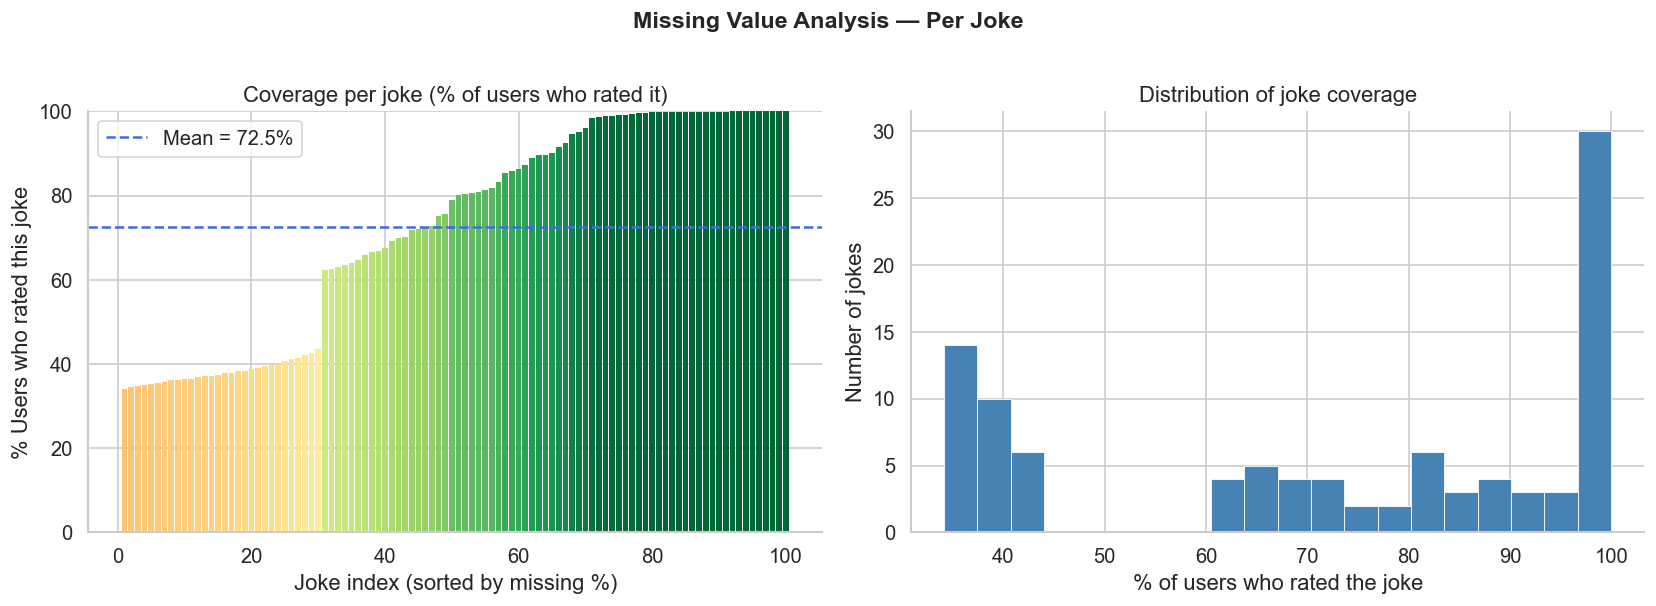

Joke with highest coverage : joke_8 (100.0%)
Joke with lowest  coverage : joke_71 (34.2%)


In [ ]:
# ── Missing values per joke ───────────────────────────────────────────────────
joke_missing_pct = ratings.isnull().mean().sort_values(ascending=False) * 100
joke_rated_pct   = 100 - joke_missing_pct

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: % rated per joke
colors = plt.cm.RdYlGn(joke_rated_pct.values / 100)
axes[0].bar(range(1, 101), joke_rated_pct.values, color=colors, width=0.85, edgecolor='none')
axes[0].axhline(joke_rated_pct.mean(), color='royalblue', lw=1.5, linestyle='--',
                label=f'Mean = {joke_rated_pct.mean():.1f}%')
axes[0].set_xlabel('Joke index (sorted by missing %)')
axes[0].set_ylabel('% Users who rated this joke')
axes[0].set_title('Coverage per joke (% of users who rated it)')
axes[0].legend()
axes[0].set_ylim(0, 100)

# Histogram of coverage percentages
axes[1].hist(joke_rated_pct.values, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('% of users who rated the joke')
axes[1].set_ylabel('Number of jokes')
axes[1].set_title('Distribution of joke coverage')

plt.suptitle('Missing Value Analysis Per Joke', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Joke with highest coverage : {joke_rated_pct.idxmax()} ({joke_rated_pct.max():.1f}%)')
print(f'Joke with lowest  coverage : {joke_rated_pct.idxmin()} ({joke_rated_pct.min():.1f}%)')

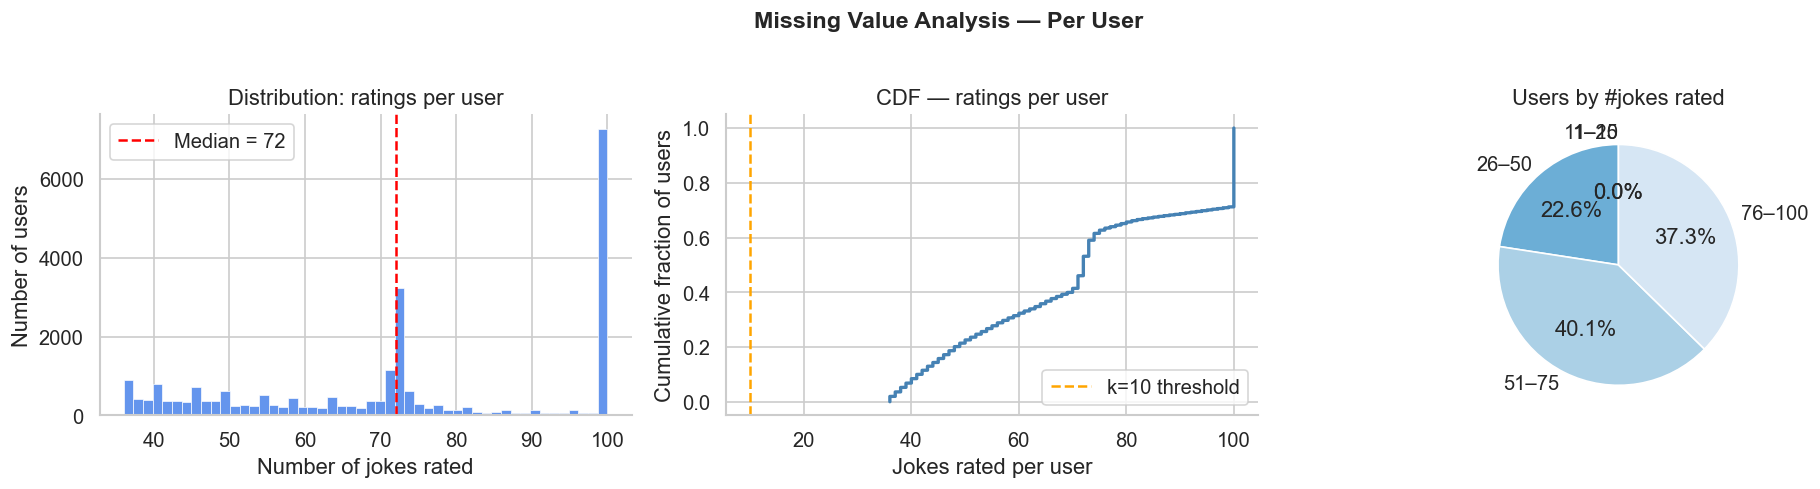

Users who rated ALL 100 jokes : 7,200
Users who rated < 10 jokes    : 0
Mean jokes rated per user     : 72.5
Median jokes rated per user   : 72


In [ ]:
# ── Missing values per user ───────────────────────────────────────────────────
user_rated_count = ratings.notna().sum(axis=1)   # How many jokes each user rated

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram of ratings per user
axes[0].hist(user_rated_count, bins=50, color='cornflowerblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Number of jokes rated')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Distribution: ratings per user')
axes[0].axvline(user_rated_count.median(), color='red', lw=1.5, linestyle='--',
                label=f'Median = {user_rated_count.median():.0f}')
axes[0].legend()

# CDF
sorted_counts = np.sort(user_rated_count)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, lw=2, color='steelblue')
axes[1].axvline(10, color='orange', lw=1.5, linestyle='--', label='k=10 threshold')
axes[1].set_xlabel('Jokes rated per user')
axes[1].set_ylabel('Cumulative fraction of users')
axes[1].set_title('CDF ratings per user')
axes[1].legend()

# Pie chart: user buckets
buckets = pd.cut(user_rated_count,
                 bins=[0, 10, 25, 50, 75, 100],
                 labels=['1–10', '11–25', '26–50', '51–75', '76–100'])
bucket_counts = buckets.value_counts().sort_index()
axes[2].pie(bucket_counts, labels=bucket_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Blues_r', len(bucket_counts)))
axes[2].set_title('Users by #jokes rated')

plt.suptitle('Missing Value Analysis Per User', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Users who rated ALL 100 jokes : {(user_rated_count == 100).sum():,}')
print(f'Users who rated < 10 jokes    : {(user_rated_count < 10).sum():,}')
print(f'Mean jokes rated per user     : {user_rated_count.mean():.1f}')
print(f'Median jokes rated per user   : {user_rated_count.median():.0f}')

## 4. Rating Distribution Analysis

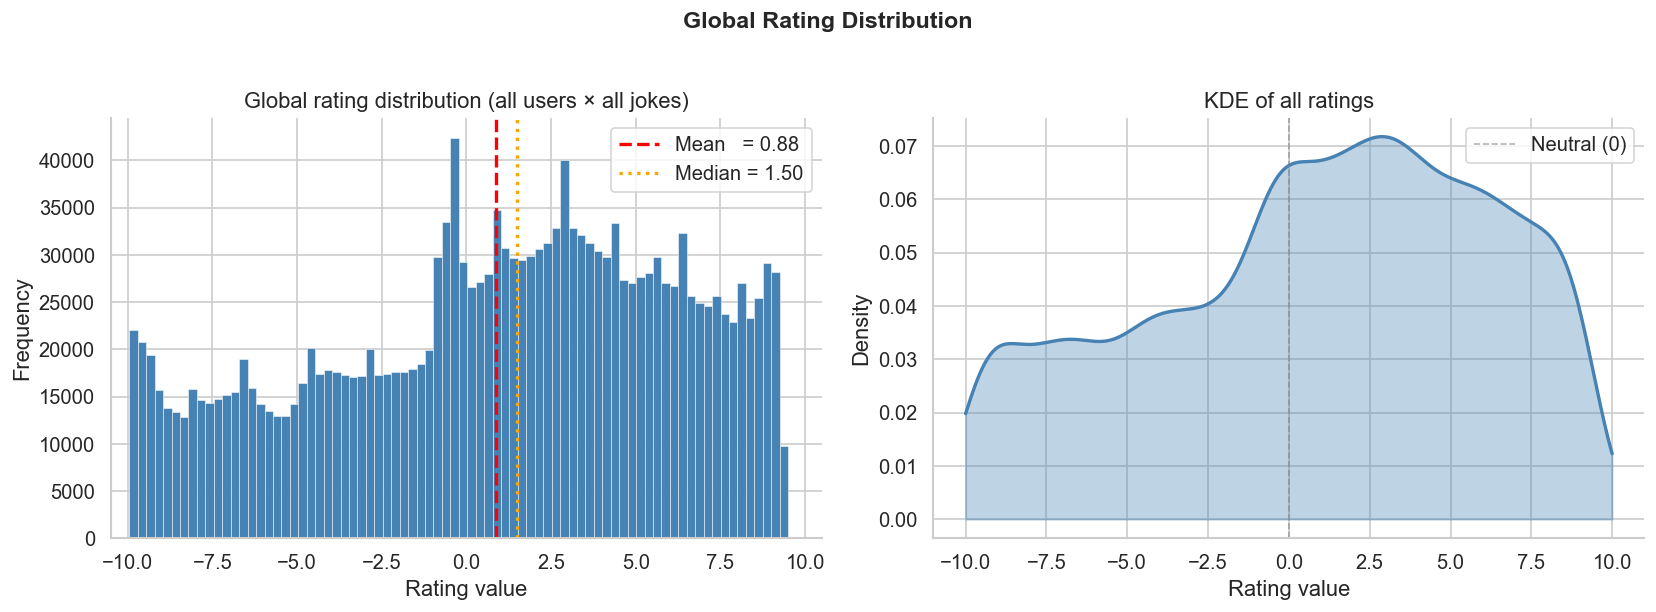

Descriptive statistics of all known ratings:
  N        = 1,810,455
  Mean     = 0.8798
  Median   = 1.5000
  Std dev  = 5.2359
  Skewness = -0.3477  (negative → left-skewed = slightly positive bias)
  Kurtosis = -0.8621
  % positive (> 0) : 59.5%
  % negative (< 0) : 40.2%
  % neutral (= 0)  : 0.3%


In [10]:
# ── Global rating distribution ────────────────────────────────────────────────
all_ratings = ratings.values.flatten()
all_ratings = all_ratings[~np.isnan(all_ratings)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(all_ratings, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(np.mean(all_ratings), color='red',    lw=2, linestyle='--',
                label=f'Mean   = {np.mean(all_ratings):.2f}')
axes[0].axvline(np.median(all_ratings), color='orange', lw=2, linestyle=':',
                label=f'Median = {np.median(all_ratings):.2f}')
axes[0].set_xlabel('Rating value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Global rating distribution (all users × all jokes)')
axes[0].legend()
axes[0].set_xlim(-10.5, 10.5)

# KDE
from scipy.stats import gaussian_kde
kde_x = np.linspace(-10, 10, 500)
kde   = gaussian_kde(all_ratings, bw_method=0.15)
axes[1].fill_between(kde_x, kde(kde_x), alpha=0.35, color='steelblue')
axes[1].plot(kde_x, kde(kde_x), lw=2, color='steelblue')
axes[1].set_xlabel('Rating value')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of all ratings')
axes[1].axvline(0, color='gray', lw=1, linestyle='--', alpha=0.6, label='Neutral (0)')
axes[1].legend()

plt.suptitle('Global Rating Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Descriptive statistics of all known ratings:')
print(f'  N        = {len(all_ratings):,}')
print(f'  Mean     = {np.mean(all_ratings):.4f}')
print(f'  Median   = {np.median(all_ratings):.4f}')
print(f'  Std dev  = {np.std(all_ratings):.4f}')
print(f'  Skewness = {skew(all_ratings):.4f}  (negative → left-skewed = slightly positive bias)')
print(f'  Kurtosis = {kurtosis(all_ratings):.4f}')
print(f'  % positive (> 0) : {(all_ratings > 0).mean():.1%}')
print(f'  % negative (< 0) : {(all_ratings < 0).mean():.1%}')
print(f'  % neutral (= 0)  : {(all_ratings == 0).mean():.1%}')

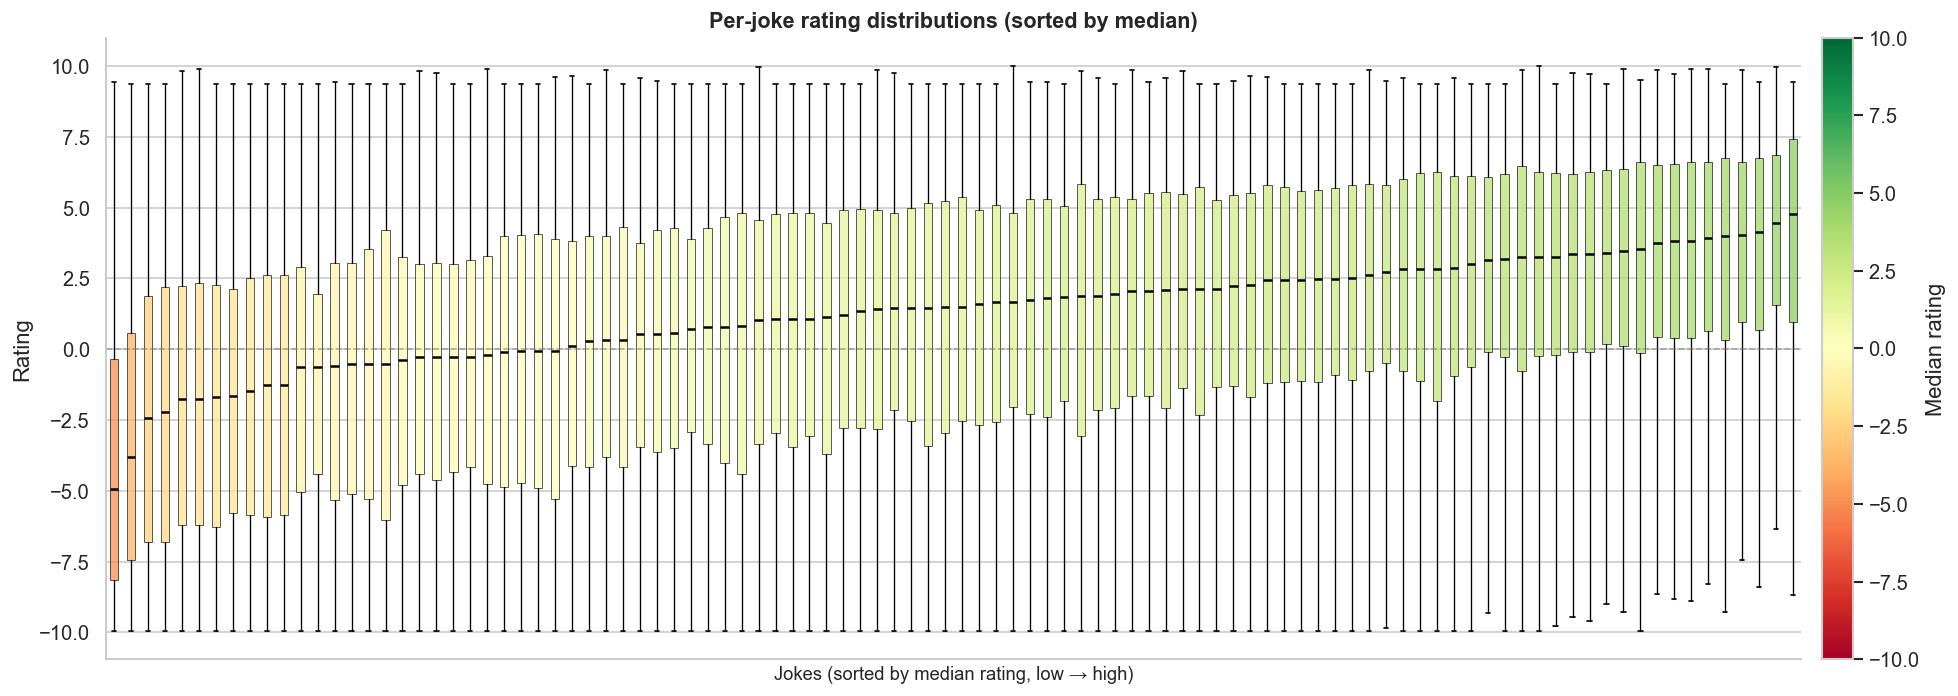

In [11]:
# ── Per-joke rating distributions (box plots) ─────────────────────────────────
# Sort jokes by their median rating
joke_medians = ratings.median().sort_values()
ratings_sorted = ratings[joke_medians.index]

fig, ax = plt.subplots(figsize=(18, 6))
data_for_box = [ratings_sorted[col].dropna().values for col in ratings_sorted.columns]

bp = ax.boxplot(data_for_box, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', lw=1.5),
                whiskerprops=dict(lw=0.8),
                boxprops=dict(lw=0.5))

# Colour boxes by median rating
cmap = plt.cm.RdYlGn
norm = plt.Normalize(-10, 10)
for patch, med in zip(bp['boxes'], joke_medians.sort_values().values):
    patch.set_facecolor(cmap(norm(med)))
    patch.set_alpha(0.75)

ax.axhline(0, color='gray', lw=1, linestyle='--', alpha=0.6)
ax.set_xticks([])
ax.set_xlabel('Jokes (sorted by median rating, low → high)', fontsize=11)
ax.set_ylabel('Rating')
ax.set_title('Per-joke rating distributions (sorted by median)', fontsize=13, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Median rating', pad=0.01)
plt.tight_layout()
plt.show()

In [12]:
# ── Per-joke summary statistics ───────────────────────────────────────────────
joke_stats = pd.DataFrame({
    'mean'   : ratings.mean(),
    'median' : ratings.median(),
    'std'    : ratings.std(),
    'min'    : ratings.min(),
    'max'    : ratings.max(),
    'n_rated': ratings.notna().sum(),
    'skewness': ratings.apply(lambda c: skew(c.dropna()))
}).sort_values('mean', ascending=False)

print('Top 10 highest-rated jokes (by mean):')
print(joke_stats.head(10).to_string())
print('\nBottom 10 lowest-rated jokes (by mean):')
print(joke_stats.tail(10).to_string())

Top 10 highest-rated jokes (by mean):
             mean  median       std   min   max  n_rated  skewness
joke_50  3.665085    4.47  4.216015 -9.95  9.95    24972 -1.054574
joke_89  3.574720    4.76  4.799183 -9.95  9.42     9564 -0.979096
joke_36  3.312500    4.03  4.281620 -9.95  9.85    24965 -0.911352
joke_27  3.189821    4.13  4.602144 -9.95  9.42    24904 -0.912099
joke_32  3.155988    3.93  4.456629 -9.95  9.90    24948 -0.856783
joke_35  3.006351    3.83  4.597890 -9.95  9.90    24952 -0.837136
joke_62  2.976021    3.74  4.547434 -9.95  9.85    24936 -0.831005
joke_29  2.972455    3.98  4.792813 -9.95  9.37    24934 -0.870937
joke_53  2.939463    3.83  4.687193 -9.95  9.71    24971 -0.886665
joke_49  2.771298    3.45  4.587945 -9.95  9.90    24957 -0.759136

Bottom 10 lowest-rated jokes (by mean):
             mean  median       std   min   max  n_rated  skewness
joke_33 -1.368648   -1.26  5.248554 -9.95  9.37    16704  0.159184
joke_4  -1.449114   -1.46  5.234654 -9.95  9.37   

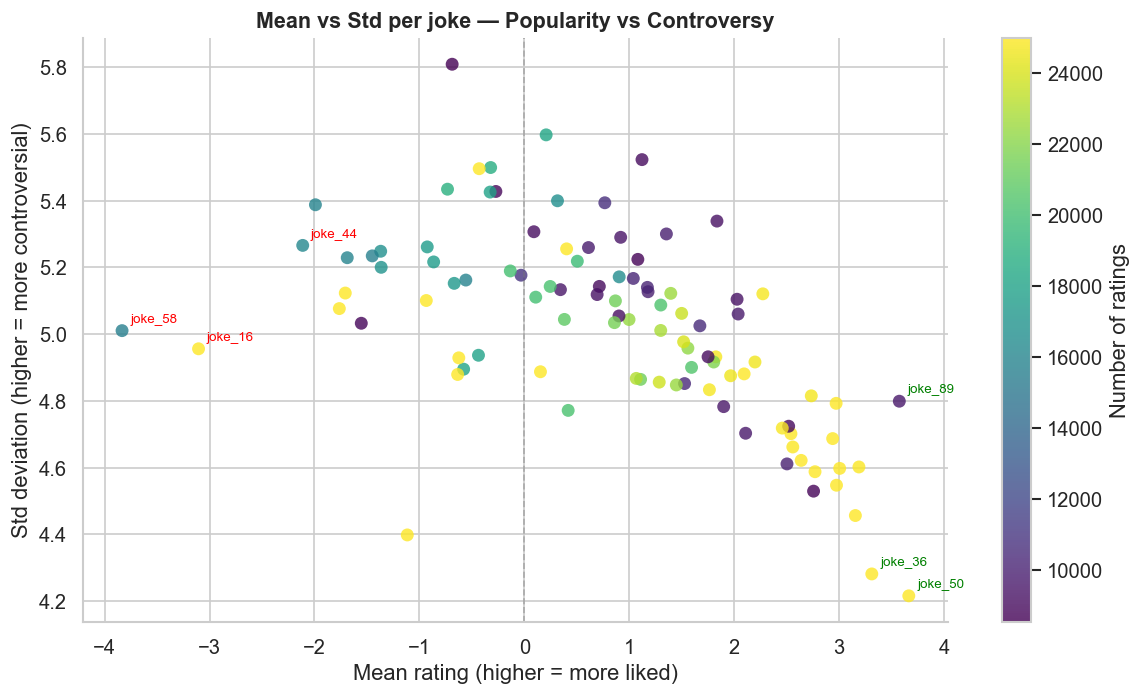

In [13]:
# ── Mean vs std per joke (controversy plot) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(joke_stats['mean'], joke_stats['std'],
                c=joke_stats['n_rated'], cmap='viridis',
                s=60, alpha=0.8, edgecolors='none')

plt.colorbar(sc, ax=ax, label='Number of ratings')

# Annotate a few extreme jokes
for joke in joke_stats.nlargest(3, 'mean').index:
    ax.annotate(joke, (joke_stats.loc[joke, 'mean'], joke_stats.loc[joke, 'std']),
                fontsize=8, xytext=(5, 5), textcoords='offset points', color='green')
for joke in joke_stats.nsmallest(3, 'mean').index:
    ax.annotate(joke, (joke_stats.loc[joke, 'mean'], joke_stats.loc[joke, 'std']),
                fontsize=8, xytext=(5, 5), textcoords='offset points', color='red')

ax.axvline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Mean rating (higher = more liked)')
ax.set_ylabel('Std deviation (higher = more controversial)')
ax.set_title('Mean vs Std per joke — Popularity vs Controversy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. User Activity Analysis

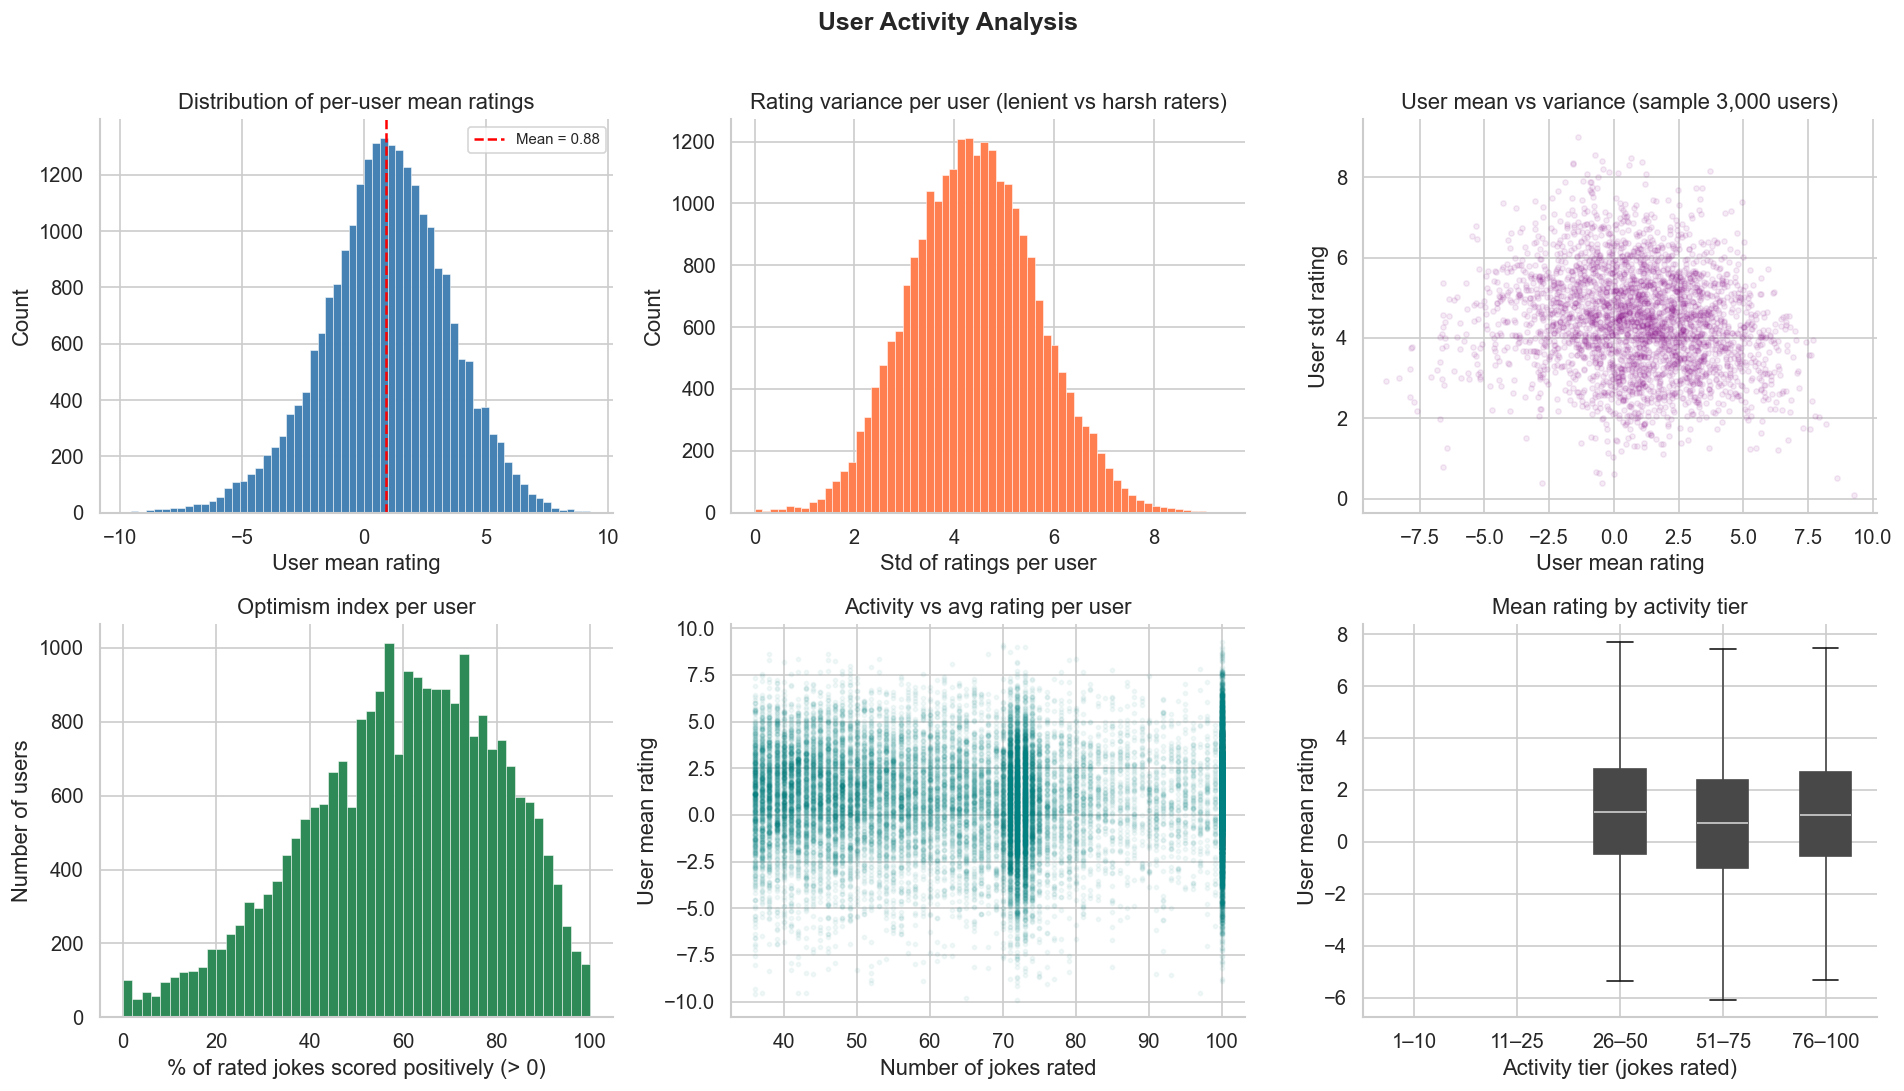

In [14]:
# ── Per-user statistics ───────────────────────────────────────────────────────
user_stats = pd.DataFrame({
    'n_rated' : ratings.notna().sum(axis=1),
    'mean_rating': ratings.mean(axis=1),
    'std_rating' : ratings.std(axis=1),
    'min_rating' : ratings.min(axis=1),
    'max_rating' : ratings.max(axis=1),
    'pct_positive': (ratings > 0).sum(axis=1) / ratings.notna().sum(axis=1)
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Distribution of user mean ratings
axes[0,0].hist(user_stats['mean_rating'], bins=60, color='steelblue', edgecolor='white', lw=0.3)
axes[0,0].axvline(user_stats['mean_rating'].mean(), color='red', lw=1.5, linestyle='--',
                   label=f"Mean = {user_stats['mean_rating'].mean():.2f}")
axes[0,0].set_xlabel('User mean rating')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distribution of per-user mean ratings')
axes[0,0].legend(fontsize=9)

# 2. Distribution of user std ratings
axes[0,1].hist(user_stats['std_rating'].dropna(), bins=60, color='coral', edgecolor='white', lw=0.3)
axes[0,1].set_xlabel('Std of ratings per user')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Rating variance per user (lenient vs harsh raters)')

# 3. Mean vs Std (scatter per user — sample 3000)
sample = user_stats.dropna().sample(min(3000, len(user_stats)), random_state=SEED)
axes[0,2].scatter(sample['mean_rating'], sample['std_rating'],
                   alpha=0.08, s=10, color='purple')
axes[0,2].set_xlabel('User mean rating')
axes[0,2].set_ylabel('User std rating')
axes[0,2].set_title('User mean vs variance (sample 3,000 users)')

# 4. Distribution of % positive ratings per user
axes[1,0].hist(user_stats['pct_positive'].dropna() * 100, bins=50,
                color='seagreen', edgecolor='white', lw=0.3)
axes[1,0].set_xlabel('% of rated jokes scored positively (> 0)')
axes[1,0].set_ylabel('Number of users')
axes[1,0].set_title('Optimism index per user')

# 5. Activity vs. mean rating
axes[1,1].scatter(user_stats['n_rated'], user_stats['mean_rating'],
                   alpha=0.05, s=6, color='teal')
axes[1,1].set_xlabel('Number of jokes rated')
axes[1,1].set_ylabel('User mean rating')
axes[1,1].set_title('Activity vs avg rating per user')

# 6. Boxplot of user means by activity tier
user_stats['activity_tier'] = pd.cut(user_stats['n_rated'],
    bins=[0,10,25,50,75,100],
    labels=['1–10','11–25','26–50','51–75','76–100'])
user_stats.boxplot(column='mean_rating', by='activity_tier', ax=axes[1,2],
                    patch_artist=True, showfliers=False)
axes[1,2].set_xlabel('Activity tier (jokes rated)')
axes[1,2].set_ylabel('User mean rating')
axes[1,2].set_title('Mean rating by activity tier')
plt.sca(axes[1,2])
plt.title('Mean rating by activity tier')

plt.suptitle('User Activity Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Joke Popularity Analysis

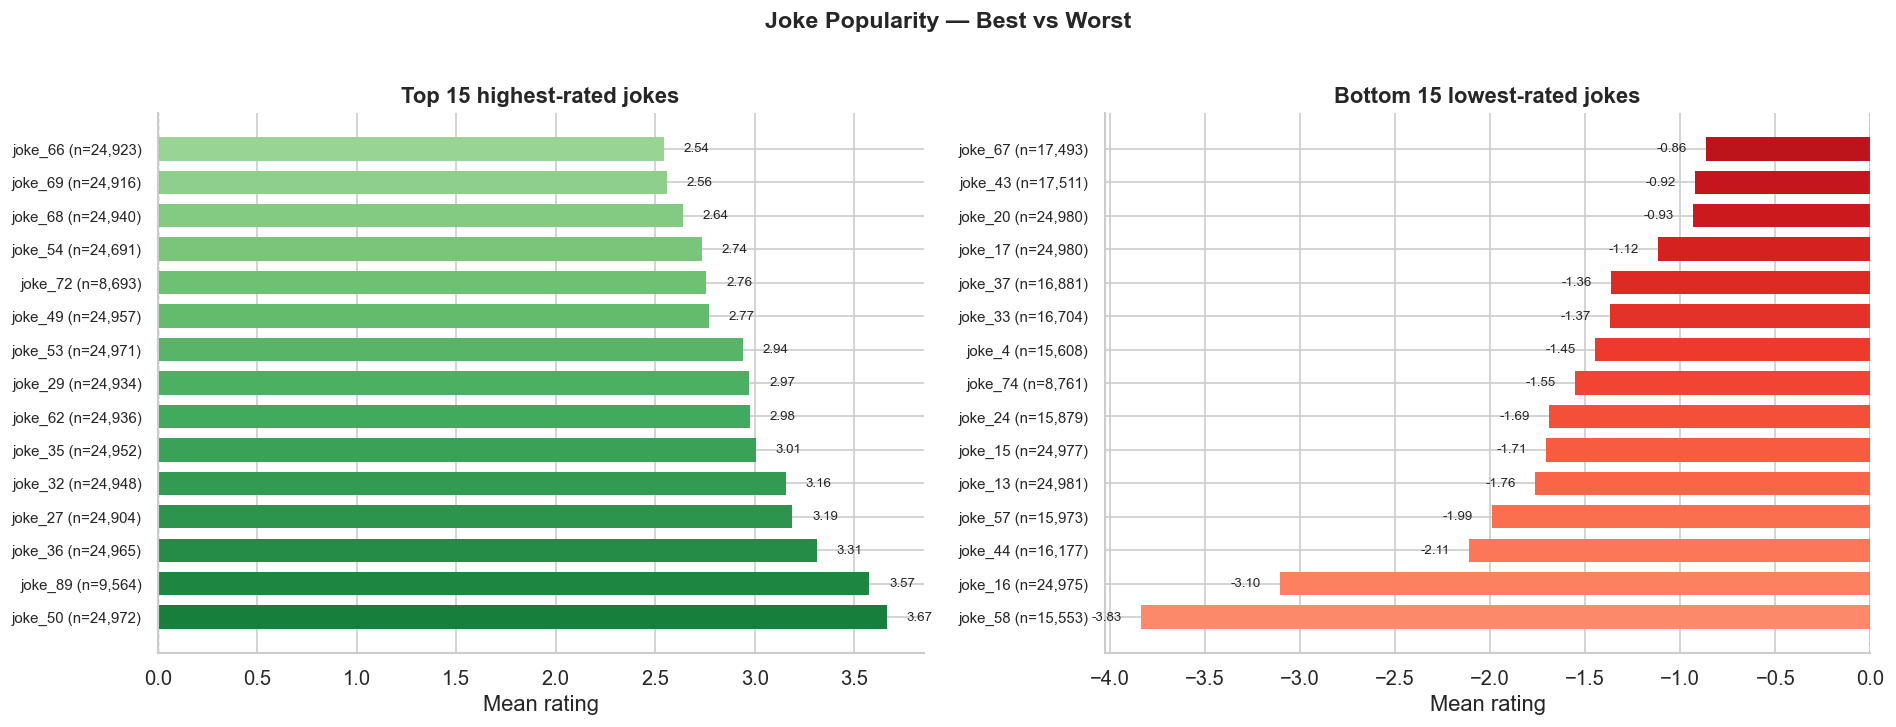

In [15]:
# ── Top and bottom jokes ──────────────────────────────────────────────────────
n_show = 15

top_jokes = joke_stats.nlargest(n_show, 'mean')
bot_jokes = joke_stats.nsmallest(n_show, 'mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top jokes
bars = axes[0].barh(range(n_show), top_jokes['mean'].values,
                     color=plt.cm.Greens(np.linspace(0.4, 0.8, n_show))[::-1],
                     edgecolor='none', height=0.7)
axes[0].set_yticks(range(n_show))
axes[0].set_yticklabels([f"{j} (n={int(joke_stats.loc[j,'n_rated']):,})" for j in top_jokes.index],
                         fontsize=9)
axes[0].set_xlabel('Mean rating')
axes[0].set_title(f'Top {n_show} highest-rated jokes', fontweight='bold')
axes[0].axvline(0, color='gray', lw=0.8, linestyle='--')
for bar, val in zip(bars, top_jokes['mean'].values):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                  f'{val:.2f}', va='center', fontsize=8)

# Bottom jokes
bars2 = axes[1].barh(range(n_show), bot_jokes['mean'].values,
                      color=plt.cm.Reds(np.linspace(0.4, 0.8, n_show)),
                      edgecolor='none', height=0.7)
axes[1].set_yticks(range(n_show))
axes[1].set_yticklabels([f"{j} (n={int(joke_stats.loc[j,'n_rated']):,})" for j in bot_jokes.index],
                         fontsize=9)
axes[1].set_xlabel('Mean rating')
axes[1].set_title(f'Bottom {n_show} lowest-rated jokes', fontweight='bold')
axes[1].axvline(0, color='gray', lw=0.8, linestyle='--')
for bar, val in zip(bars2, bot_jokes['mean'].values):
    axes[1].text(val - 0.1, bar.get_y() + bar.get_height()/2,
                  f'{val:.2f}', va='center', ha='right', fontsize=8)

plt.suptitle('Joke Popularity — Best vs Worst', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Sparsity Visualization

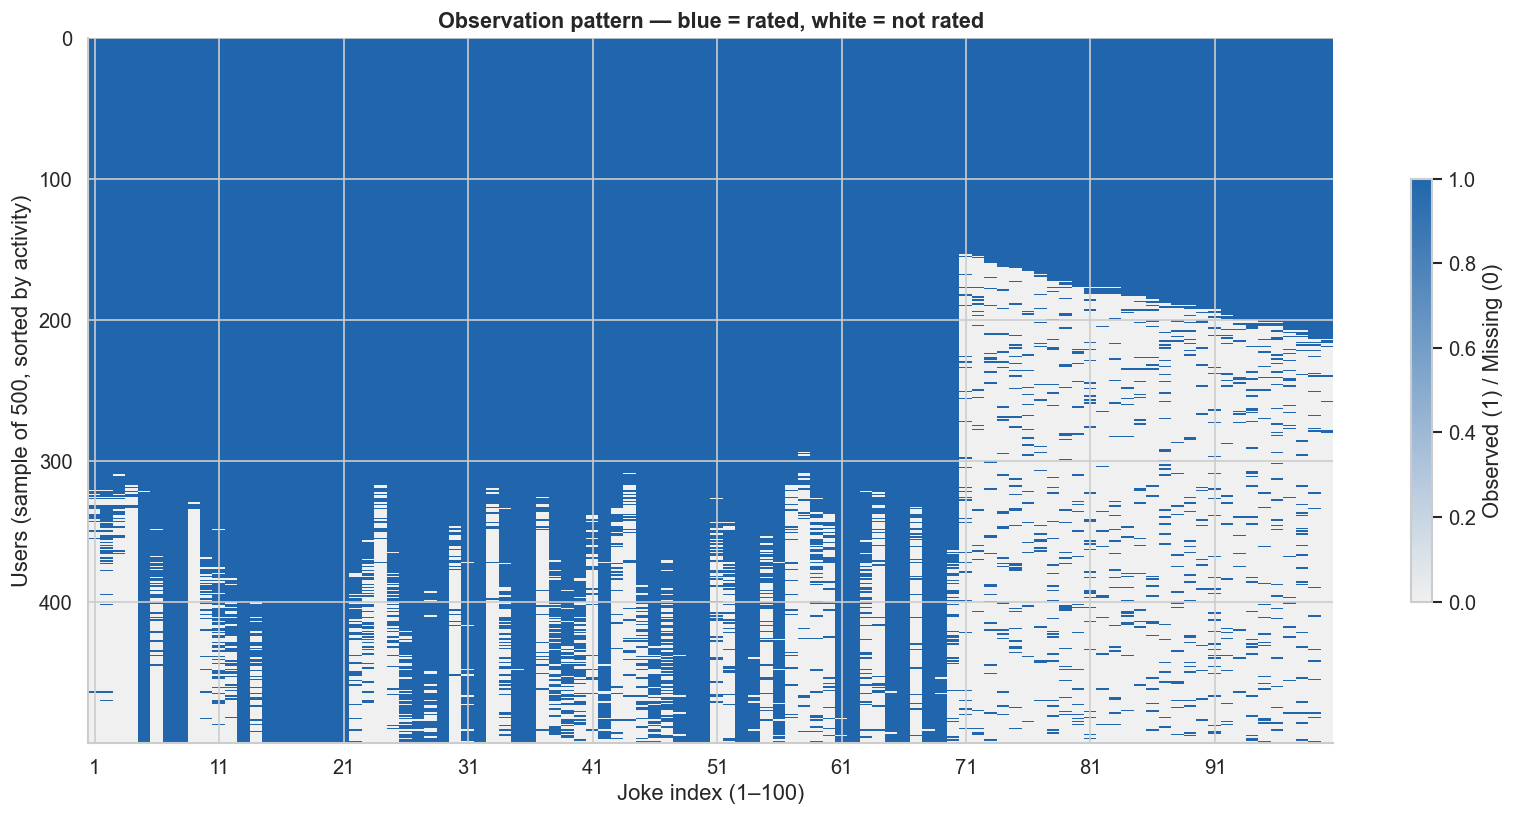

Sparsity in this sample: 26.2%


In [16]:
# ── Sparsity heatmap (sampled rows) ──────────────────────────────────────────
# Sample 500 users to keep the plot readable
n_sample = 500
sample_users = ratings.sample(n_sample, random_state=SEED)

# Sort sampled users by activity level
sample_users = sample_users.loc[sample_users.notna().sum(axis=1).sort_values(ascending=False).index]

# Create observed/missing binary matrix
observed = sample_users.notna().astype(int)

fig, ax = plt.subplots(figsize=(14, 7))
cmap_sparse = LinearSegmentedColormap.from_list('obs', ['#f0f0f0', '#2166ac'])
im = ax.imshow(observed.values, aspect='auto', cmap=cmap_sparse, interpolation='nearest')
ax.set_xlabel('Joke index (1–100)')
ax.set_ylabel(f'Users (sample of {n_sample}, sorted by activity)')
ax.set_title('Observation pattern — blue = rated, white = not rated', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 100, 10))
ax.set_xticklabels(range(1, 101, 10))
plt.colorbar(im, ax=ax, label='Observed (1) / Missing (0)', shrink=0.6)
plt.tight_layout()
plt.show()

print(f"Sparsity in this sample: {(observed == 0).values.mean():.1%}")

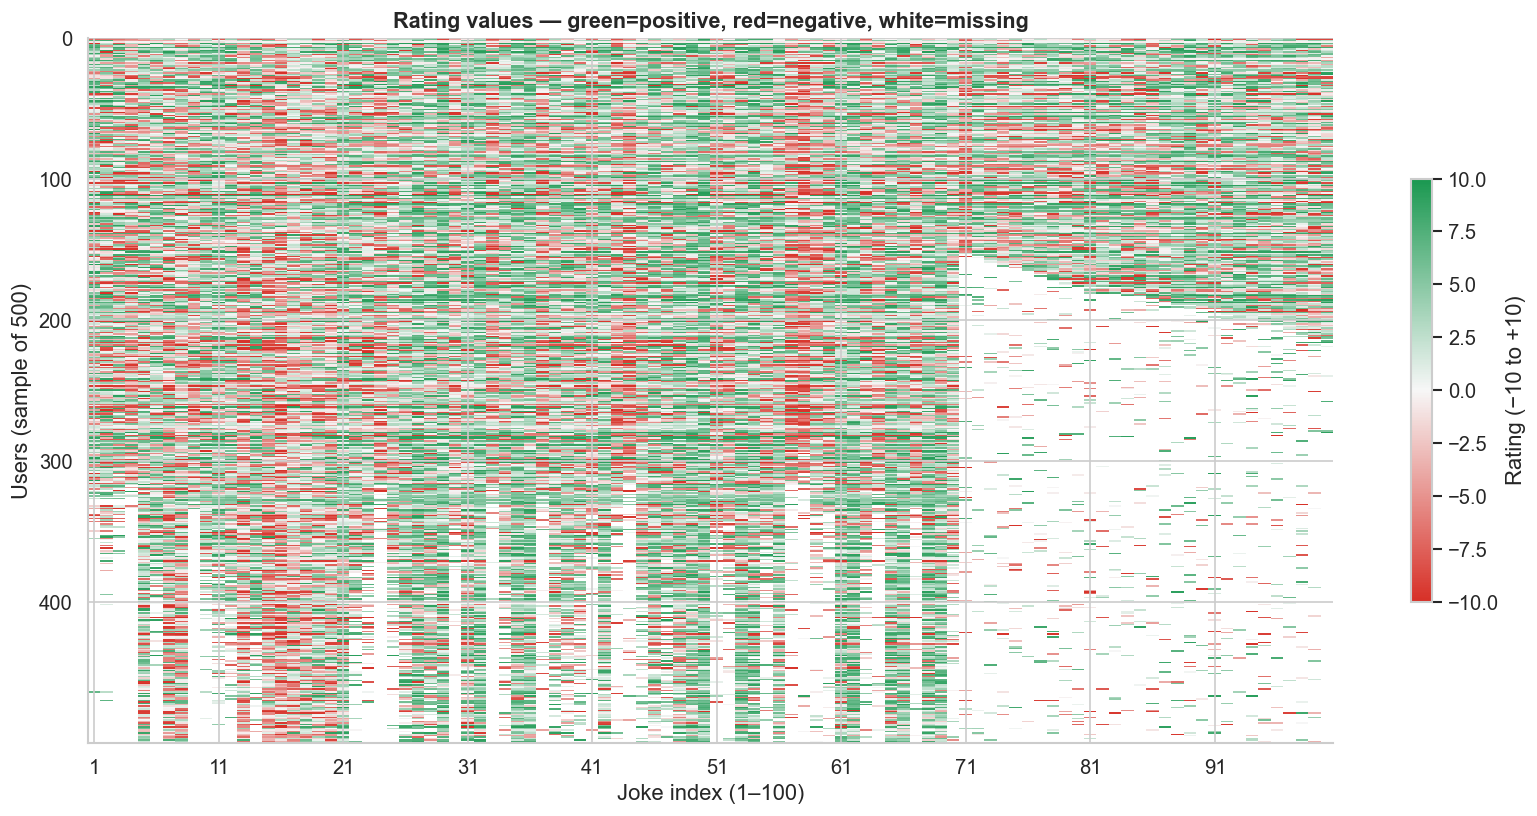

In [17]:
# ── Rating value heatmap (sampled users) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
cmap_rating = LinearSegmentedColormap.from_list('rating', ['#d73027','#f7f7f7','#1a9850'])

im2 = ax.imshow(sample_users.values, aspect='auto', cmap=cmap_rating,
                vmin=-10, vmax=10, interpolation='nearest')
ax.set_xlabel('Joke index (1–100)')
ax.set_ylabel(f'Users (sample of {n_sample})')
ax.set_title('Rating values — green=positive, red=negative, white=missing', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 100, 10))
ax.set_xticklabels(range(1, 101, 10))
plt.colorbar(im2, ax=ax, label='Rating (−10 to +10)', shrink=0.6)
plt.tight_layout()
plt.show()

## 8. Correlation & Similarity Analysis

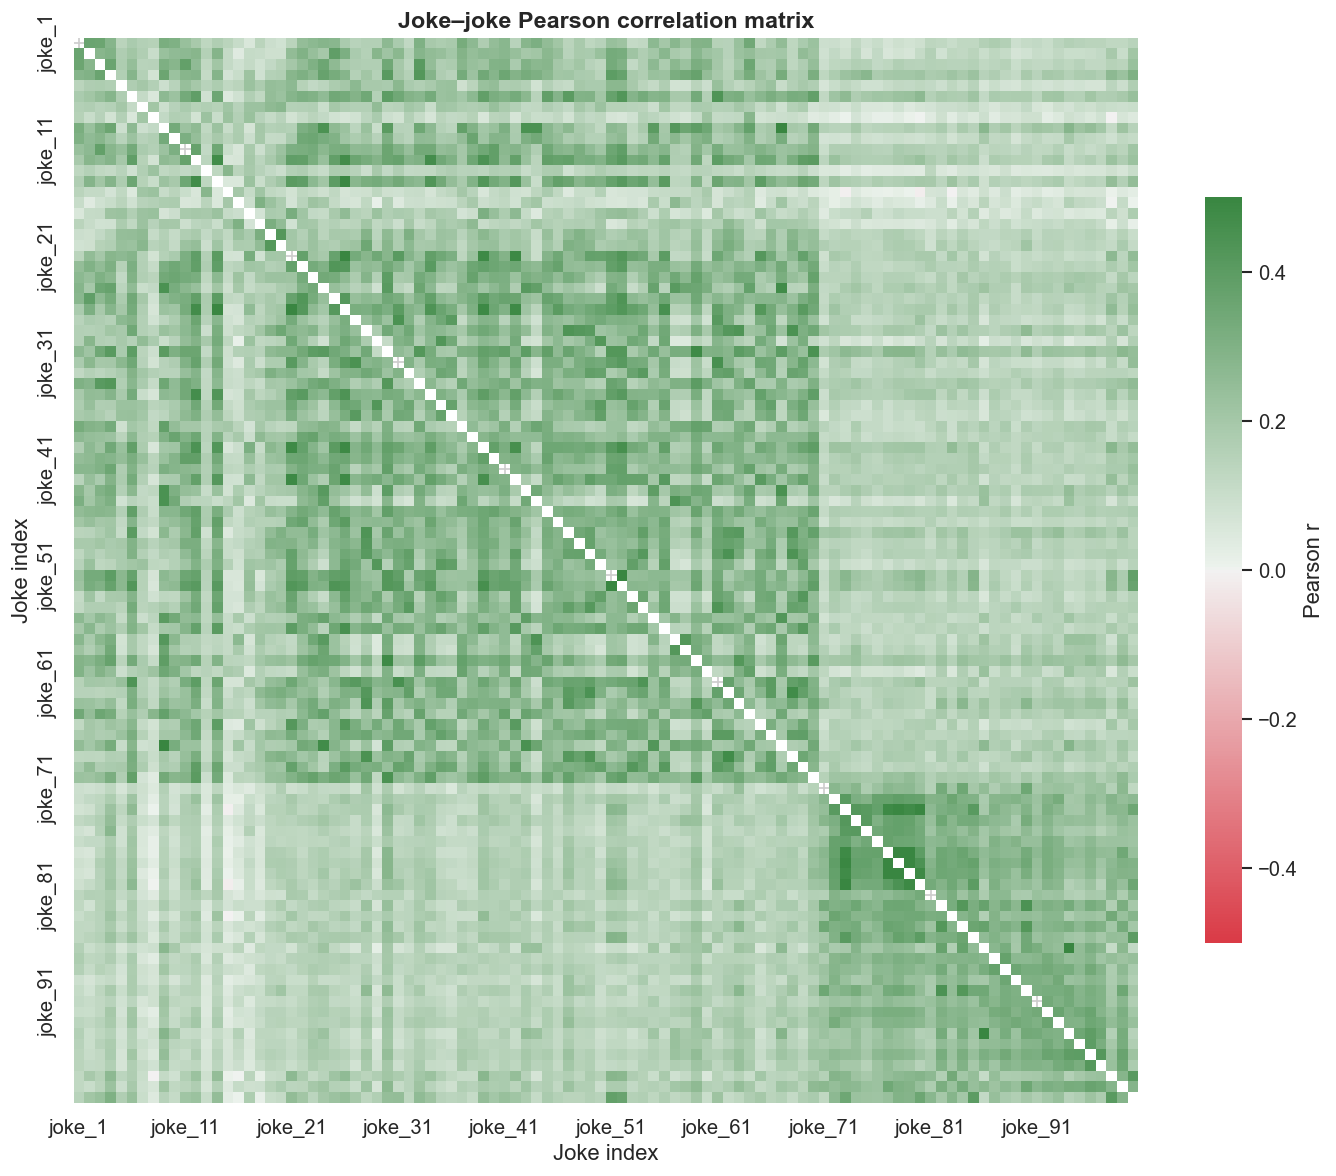

Top 10 most positively correlated joke pairs:
joke_52  joke_51    0.563166
joke_51  joke_52    0.563166
joke_86  joke_94    0.558401
joke_94  joke_86    0.558401
joke_78  joke_79    0.539891
joke_79  joke_78    0.539891
joke_78  joke_77    0.530707
joke_77  joke_78    0.530707
joke_73  joke_80    0.528673
joke_80  joke_73    0.528673

Top 10 most negatively correlated joke pairs:
joke_16  joke_98    0.001077
joke_98  joke_16    0.001077
joke_15  joke_83   -0.002031
joke_83  joke_15   -0.002031
joke_8   joke_98   -0.003671
joke_98  joke_8    -0.003671
joke_73  joke_15   -0.005505
joke_15  joke_73   -0.005505
joke_80  joke_15   -0.015215
joke_15  joke_80   -0.015215


In [18]:
# ── Joke-joke Pearson correlation matrix ──────────────────────────────────────
# Fill NaN with column mean before computing correlation
ratings_filled = ratings.fillna(ratings.mean())
joke_corr = ratings_filled.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(100, dtype=bool)   # hide diagonal
cmap_corr = sns.diverging_palette(10, 130, as_cmap=True)

sns.heatmap(joke_corr, ax=ax, cmap=cmap_corr, center=0,
            vmin=-0.5, vmax=0.5,
            xticklabels=10, yticklabels=10,
            linewidths=0, mask=mask,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.7})
ax.set_title('Joke–joke Pearson correlation matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Joke index')
ax.set_ylabel('Joke index')
plt.tight_layout()
plt.show()

# Find most correlated pairs
corr_vals = joke_corr.where(~mask).stack().sort_values(ascending=False)
print('Top 10 most positively correlated joke pairs:')
print(corr_vals.head(10).to_string())
print('\nTop 10 most negatively correlated joke pairs:')
print(corr_vals.tail(10).to_string())

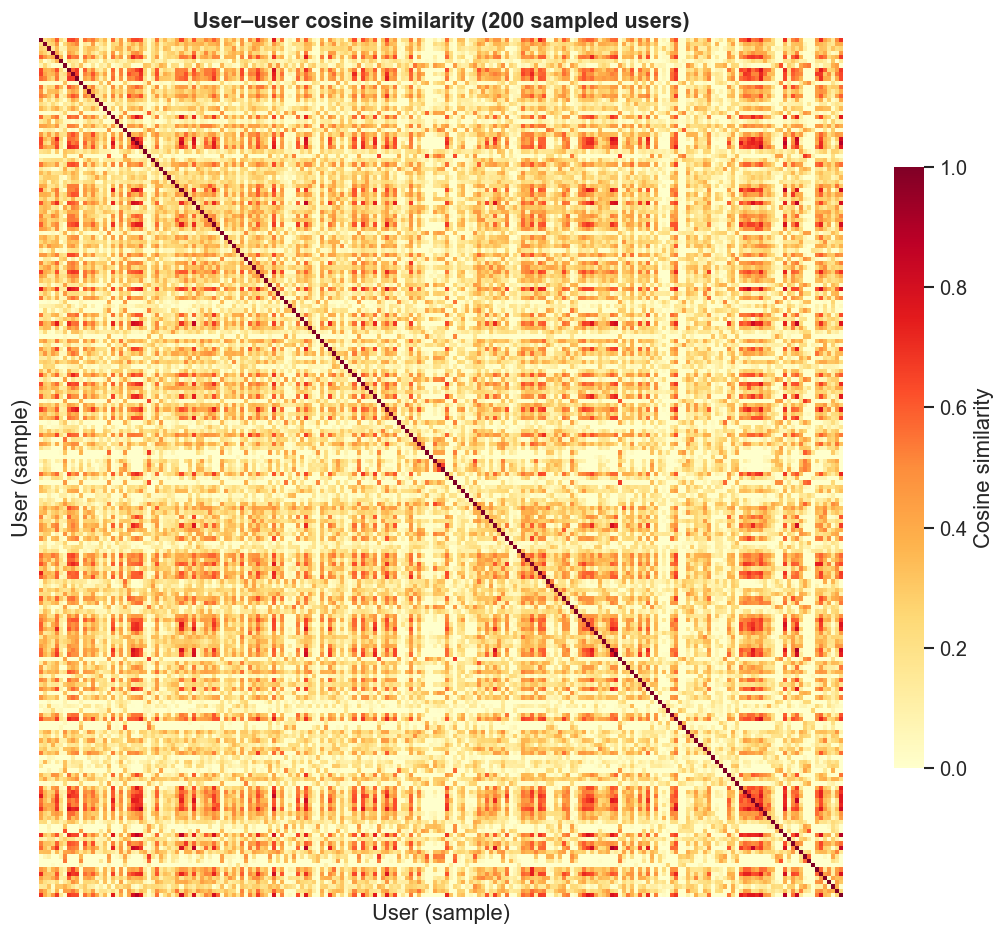

User-user cosine similarity (off-diagonal):
  Mean   : 0.1738
  Median : 0.1838
  Std    : 0.2431


In [19]:
# ── User-user cosine similarity (sample 200 users) ────────────────────────────
n_u = 200
user_sample = ratings_filled.sample(n_u, random_state=SEED)
user_sim = cosine_similarity(user_sample)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(user_sim, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Cosine similarity', 'shrink': 0.7})
ax.set_title(f'User–user cosine similarity ({n_u} sampled users)', fontsize=13, fontweight='bold')
ax.set_xlabel('User (sample)')
ax.set_ylabel('User (sample)')
plt.tight_layout()
plt.show()

sim_flat = user_sim[np.triu_indices_from(user_sim, k=1)]
print(f'User-user cosine similarity (off-diagonal):')
print(f'  Mean   : {sim_flat.mean():.4f}')
print(f'  Median : {np.median(sim_flat):.4f}')
print(f'  Std    : {sim_flat.std():.4f}')

## 9. User Segmentation via K-Means Clustering

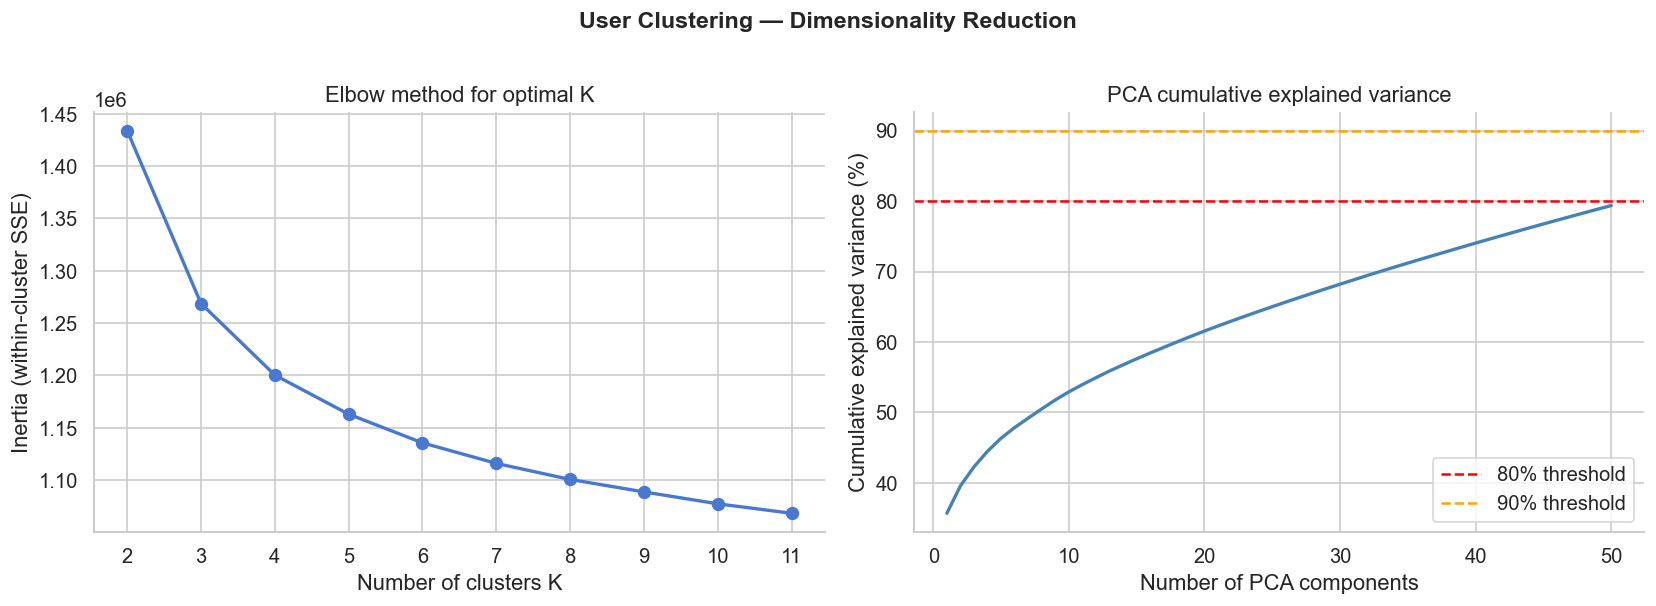

Components needed for 80% variance: 1
Components needed for 90% variance: 1


In [20]:
# ── PCA → K-Means on user rating vectors ─────────────────────────────────────
# Step 1: Fill missing with user means (mean-imputation)
user_means_vec = ratings.mean(axis=1)
ratings_imputed = ratings.T.fillna(user_means_vec).T   # shape: (n_users, 100)

# Step 2: Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ratings_imputed)

# Step 3: PCA to 50 components (for speed)
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# Elbow method
inertias = []
K_range = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', lw=2, ms=7)
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method for optimal K')
axes[0].set_xticks(list(K_range))

# PCA variance explained
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, 51), cum_var, lw=2, color='steelblue')
axes[1].axhline(80, color='red', lw=1.5, linestyle='--', label='80% threshold')
axes[1].axhline(90, color='orange', lw=1.5, linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of PCA components')
axes[1].set_ylabel('Cumulative explained variance (%)')
axes[1].set_title('PCA cumulative explained variance')
axes[1].legend()

plt.suptitle('User Clustering — Dimensionality Reduction', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

n80 = np.argmax(cum_var >= 80) + 1
n90 = np.argmax(cum_var >= 90) + 1
print(f'Components needed for 80% variance: {n80}')
print(f'Components needed for 90% variance: {n90}')

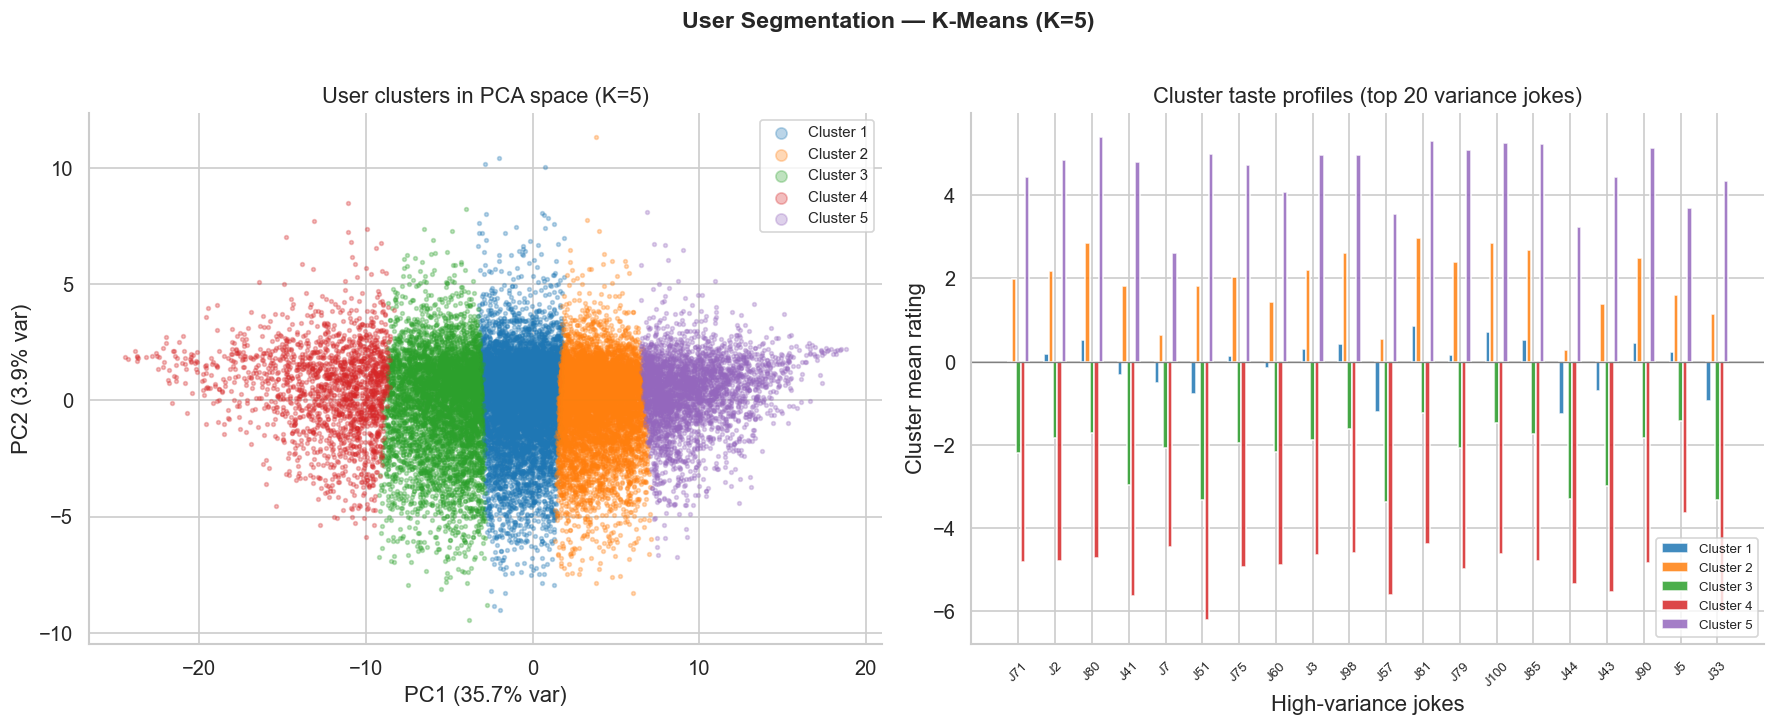

Cluster sizes:
  Cluster 1: 7,924 users (31.7%)
  Cluster 2: 6,863 users (27.5%)
  Cluster 3: 5,287 users (21.2%)
  Cluster 4: 1,811 users (7.2%)
  Cluster 5: 3,098 users (12.4%)


In [21]:
# ── Cluster users and visualise in 2D ────────────────────────────────────────
K_BEST = 5   # adjust based on elbow — typically 4–6 for Jester

km = KMeans(n_clusters=K_BEST, n_init=15, random_state=SEED)
cluster_labels = km.fit_predict(X_pca)

# 2D projection for visualisation
pca2 = PCA(n_components=2, random_state=SEED)
X_2d = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
palette = sns.color_palette('tab10', K_BEST)
for k in range(K_BEST):
    mask_k = cluster_labels == k
    axes[0].scatter(X_2d[mask_k, 0], X_2d[mask_k, 1],
                     s=5, alpha=0.3, color=palette[k], label=f'Cluster {k+1}')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
axes[0].set_title(f'User clusters in PCA space (K={K_BEST})')
axes[0].legend(markerscale=3, fontsize=9)

# Cluster mean rating profiles (radar-like bar chart)
# Take 20 jokes with highest variance for readability
high_var_jokes = ratings.var().nlargest(20).index
cluster_profiles = pd.DataFrame({'cluster': cluster_labels})
cluster_profiles = cluster_profiles.join(ratings_imputed[high_var_jokes].reset_index(drop=True))
cluster_means = cluster_profiles.groupby('cluster')[high_var_jokes].mean()

x = np.arange(20)
width = 0.12
for k in range(K_BEST):
    axes[1].bar(x + k * width, cluster_means.iloc[k].values, width=width,
                 color=palette[k], label=f'Cluster {k+1}', alpha=0.85)
axes[1].set_xticks(x + width * (K_BEST-1)/2)
axes[1].set_xticklabels([j.replace('joke_','J') for j in high_var_jokes], rotation=45, fontsize=8)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_xlabel('High-variance jokes')
axes[1].set_ylabel('Cluster mean rating')
axes[1].set_title('Cluster taste profiles (top 20 variance jokes)')
axes[1].legend(fontsize=8)

plt.suptitle(f'User Segmentation — K-Means (K={K_BEST})', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cluster sizes
unique, counts = np.unique(cluster_labels, return_counts=True)
print('Cluster sizes:')
for u, c in zip(unique, counts):
    print(f'  Cluster {u+1}: {c:,} users ({c/len(cluster_labels):.1%})')

## 10. Content Analysis Joke Texts (NLP)

In [30]:
# ── NLP analysis on joke texts ────────────────────────────────────────────────
from pathlib import Path
import re

from bs4 import BeautifulSoup

# Load the real joke texts from the HTML files in Data/jokes.
jokes_dir = Path('../Data/jokes')
if not jokes_dir.exists() or not jokes_dir.is_dir():
    raise FileNotFoundError('Could not find the jokes folder at ../Data/jokes')

def _joke_sort_key(path):
    match = re.search(r'init(\d+)\.html$', path.name, flags=re.IGNORECASE)
    return int(match.group(1)) if match else path.name.lower()

def _extract_joke_text(path):
    html = path.read_text(encoding='latin-1', errors='ignore')
    match = re.search(r'<!--begin of joke -->(.*?)<!--end of joke -->', html, flags=re.IGNORECASE | re.DOTALL)
    fragment = match.group(1) if match else html
    text = BeautifulSoup(fragment, 'html.parser').get_text(' ', strip=True)
    return re.sub(r'\s+', ' ', text).strip()

joke_files = sorted(jokes_dir.glob('init*.html'), key=_joke_sort_key)
if not joke_files:
    raise FileNotFoundError(f'No init*.html files found in {jokes_dir}')

joke_texts = [_extract_joke_text(path) for path in joke_files]
print(f'Loaded {len(joke_texts)} joke texts from: {jokes_dir.resolve()}')
print('First joke text:')
print(joke_texts[0])

# Basic text stats
lengths = [len(t.split()) for t in joke_texts]
print(f'Joke text statistics:')
print(f'  Min words   : {min(lengths)}')
print(f'  Max words   : {max(lengths)}')
print(f'  Mean words  : {np.mean(lengths):.1f}')
print(f'  Median words: {np.median(lengths):.0f}')

Loaded 100 joke texts from: D:\Jokes-RS\Data\jokes
First joke text:
A man visits the doctor. The doctor says "I have bad news for you.You have cancer and Alzheimer's disease". The man replies "Well,thank God I don't have cancer!"
Joke text statistics:
  Min words   : 12
  Max words   : 218
  Mean words  : 58.2
  Median words: 41


TF-IDF matrix shape: (100, 300)


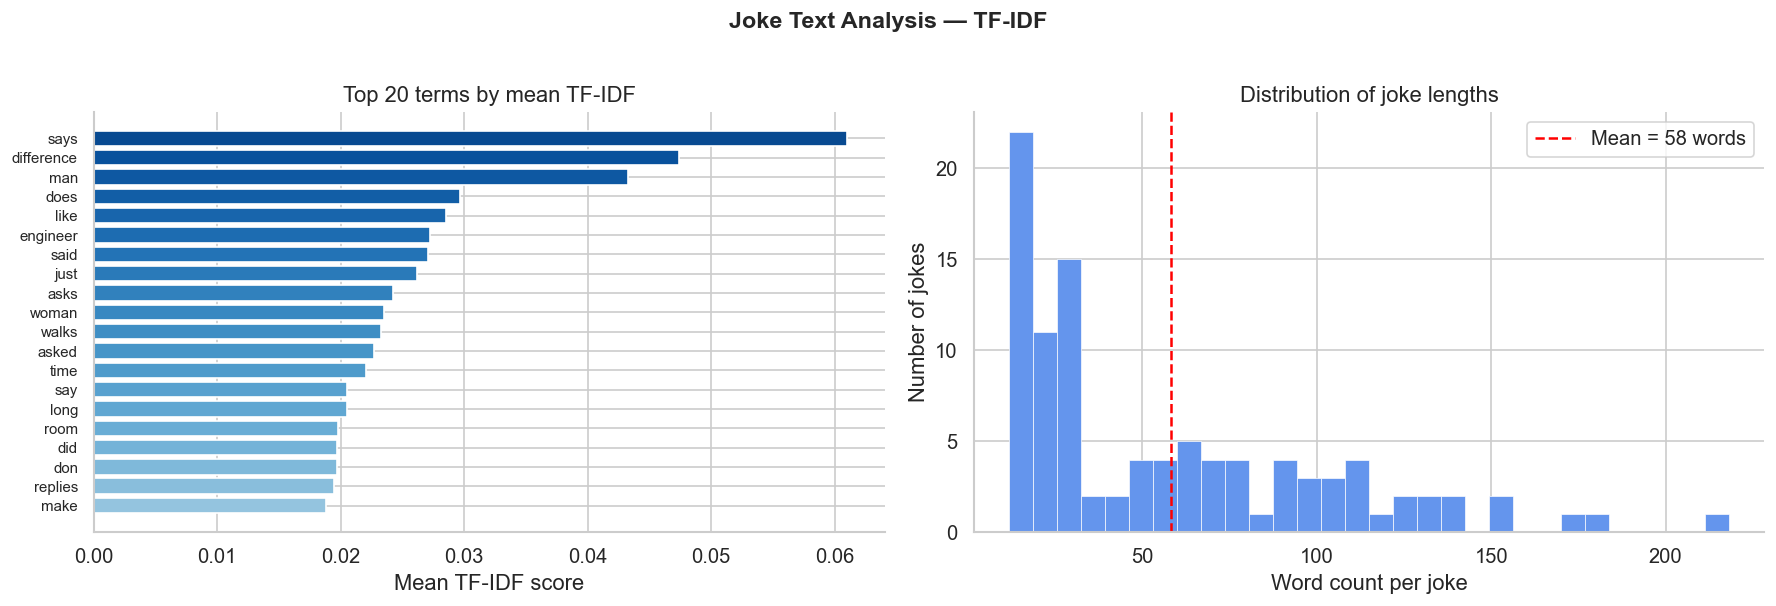

In [31]:
# ── TF-IDF feature extraction ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=300,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)
X_tfidf = tfidf.fit_transform(joke_texts)   # shape: (100, ≤300)
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

# Top terms overall
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top TF-IDF terms
axes[0].barh(range(20), mean_tfidf[top_indices][::-1],
              color=plt.cm.Blues(np.linspace(0.4, 0.9, 20)))
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feature_names[top_indices][::-1], fontsize=9)
axes[0].set_xlabel('Mean TF-IDF score')
axes[0].set_title('Top 20 terms by mean TF-IDF')

# Joke length distribution
axes[1].hist(lengths, bins=30, color='cornflowerblue', edgecolor='white', lw=0.4)
axes[1].axvline(np.mean(lengths), color='red', lw=1.5, linestyle='--',
                 label=f'Mean = {np.mean(lengths):.0f} words')
axes[1].set_xlabel('Word count per joke')
axes[1].set_ylabel('Number of jokes')
axes[1].set_title('Distribution of joke lengths')
axes[1].legend()

plt.suptitle('Joke Text Analysis — TF-IDF', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

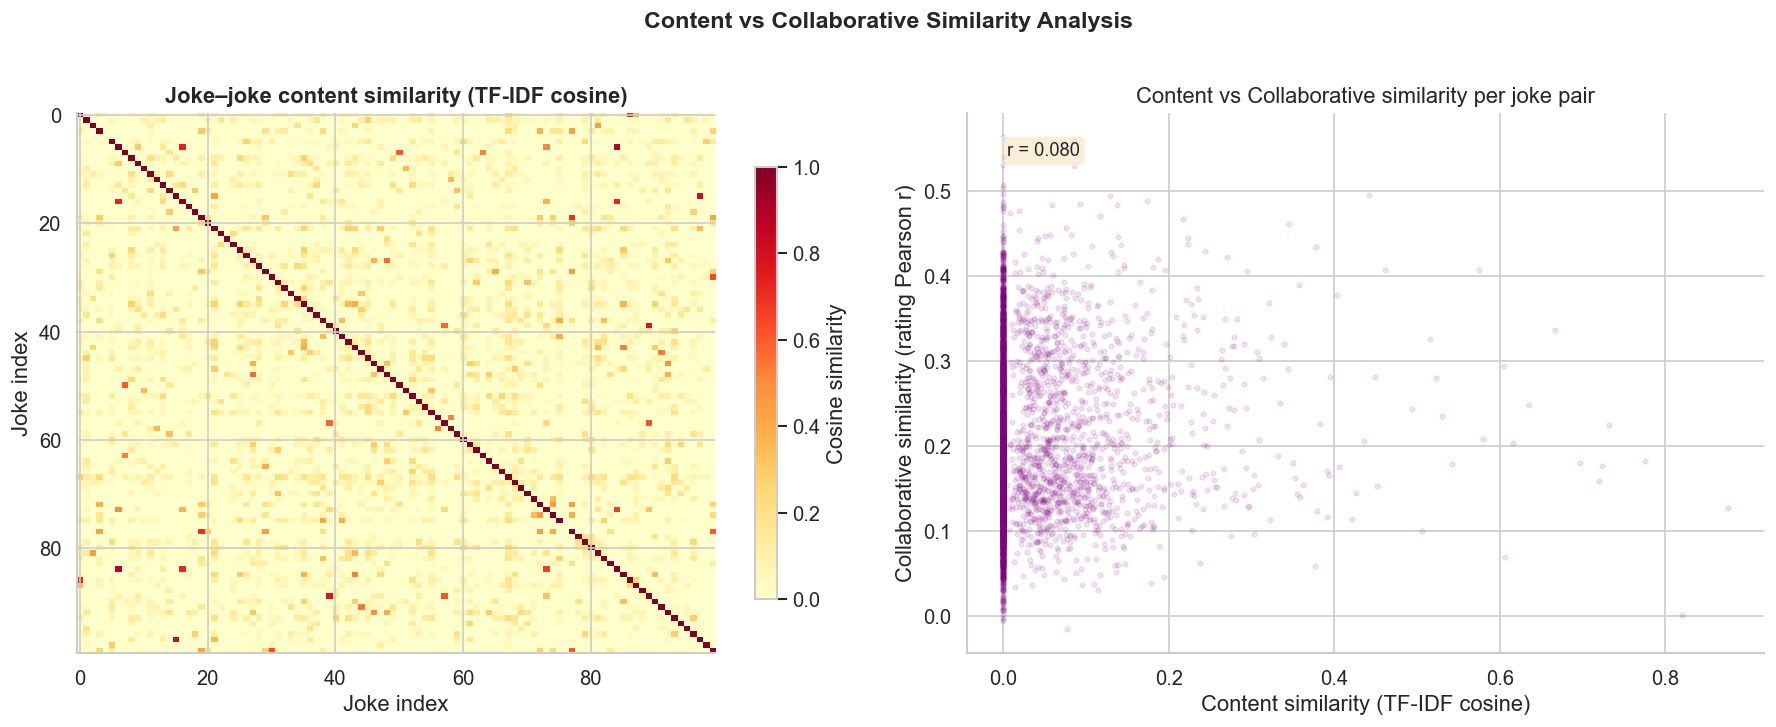

Correlation between content and collaborative similarity: r = 0.0801
Interpretation: Low correlation justifies a hybrid approach (each adds unique signal).


In [32]:
# ── Joke content similarity heatmap ──────────────────────────────────────────
joke_content_sim = cosine_similarity(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Content similarity heatmap
im = axes[0].imshow(joke_content_sim, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[0], label='Cosine similarity', shrink=0.8)
axes[0].set_title('Joke–joke content similarity (TF-IDF cosine)', fontweight='bold')
axes[0].set_xlabel('Joke index')
axes[0].set_ylabel('Joke index')

# Collaborative vs content similarity comparison (using mean rating as proxy)
collab_sim_flat  = joke_corr.values[np.triu_indices(100, k=1)]
content_sim_flat = joke_content_sim[np.triu_indices(100, k=1)]

axes[1].scatter(content_sim_flat, collab_sim_flat, alpha=0.1, s=8, color='purple')
axes[1].set_xlabel('Content similarity (TF-IDF cosine)')
axes[1].set_ylabel('Collaborative similarity (rating Pearson r)')
axes[1].set_title('Content vs Collaborative similarity per joke pair')

corr_coef = np.corrcoef(content_sim_flat, collab_sim_flat)[0, 1]
axes[1].text(0.05, 0.92, f'r = {corr_coef:.3f}', transform=axes[1].transAxes,
              fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Content vs Collaborative Similarity Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Correlation between content and collaborative similarity: r = {corr_coef:.4f}')
print('Interpretation: Low correlation justifies a hybrid approach (each adds unique signal).')

## 11. Key EDA Summary & Observations

In [33]:
# ── Comprehensive summary table ───────────────────────────────────────────────
print('=' * 65)
print('EDA SUMMARY — JESTER DATASET 1')
print('=' * 65)
print()
print('DATASET STRUCTURE')
print(f'  Users (total)              : {ratings.shape[0]:,}')
print(f'  Jokes (total)              : {ratings.shape[1]}')
print(f'  Total cells                : {ratings.size:,}')
print(f'  Known ratings              : {ratings.notna().sum().sum():,}')
print(f'  Sparsity                   : {ratings.isnull().mean().mean():.1%}')
print()
print('RATING STATISTICS')
print(f'  Global mean rating         : {ratings.mean().mean():.3f}')
print(f'  Global std                 : {ratings.std().mean():.3f}')
print(f'  Skewness (global)          : {skew(ratings.values.flatten()[~np.isnan(ratings.values.flatten())]):.3f}')
print(f'  % positive ratings (> 0)   : {(ratings > 0).sum().sum() / ratings.notna().sum().sum():.1%}')
print()
print('USER ACTIVITY')
print(f'  Mean jokes rated/user      : {user_stats["n_rated"].mean():.1f}')
print(f'  Median jokes rated/user    : {user_stats["n_rated"].median():.0f}')
print(f'  Users who rated all 100    : {(user_stats["n_rated"] == 100).sum():,}')
print(f'  Users who rated < 10       : {(user_stats["n_rated"] < 10).sum():,}')
print()
print('JOKE CHARACTERISTICS')
print(f'  Most popular joke (mean)   : {joke_stats["mean"].idxmax()} (mean={joke_stats["mean"].max():.2f})')
print(f'  Least popular joke (mean)  : {joke_stats["mean"].idxmin()} (mean={joke_stats["mean"].min():.2f})')
print(f'  Most rated joke            : {joke_stats["n_rated"].idxmax()} ({joke_stats["n_rated"].max():,} ratings)')
print(f'  Std of joke means          : {joke_stats["mean"].std():.3f}  (spread of popularity)')
print()
print('MODELLING IMPLICATIONS')
print('  [1] ~30% sparsity → matrix factorisation handles this well')
print('  [2] Continuous ratings (not binary) → regression, not classification')
print('  [3] User mean-centering needed (high variance in user bias)')
print('  [4] Low content vs collab correlation → hybrid model is justified')
print('  [5] Some users rated all 100 jokes → useful as "cold start" anchors')
print('=' * 65)

EDA SUMMARY — JESTER DATASET 1

DATASET STRUCTURE
  Users (total)              : 24,983
  Jokes (total)              : 100
  Total cells                : 2,498,300
  Known ratings              : 1,810,455
  Sparsity                   : 27.5%

RATING STATISTICS
  Global mean rating         : 0.823
  Global std                 : 5.019
  Skewness (global)          : -0.348
  % positive ratings (> 0)   : 59.5%

USER ACTIVITY
  Mean jokes rated/user      : 72.5
  Median jokes rated/user    : 72
  Users who rated all 100    : 7,200
  Users who rated < 10       : 0

JOKE CHARACTERISTICS
  Most popular joke (mean)   : joke_50 (mean=3.67)
  Least popular joke (mean)  : joke_58 (mean=-3.83)
  Most rated joke            : joke_8 (24,981 ratings)
  Std of joke means          : 1.546  (spread of popularity)

MODELLING IMPLICATIONS
  [1] ~30% sparsity → matrix factorisation handles this well
  [2] Continuous ratings (not binary) → regression, not classification
  [3] User mean-centering needed (high

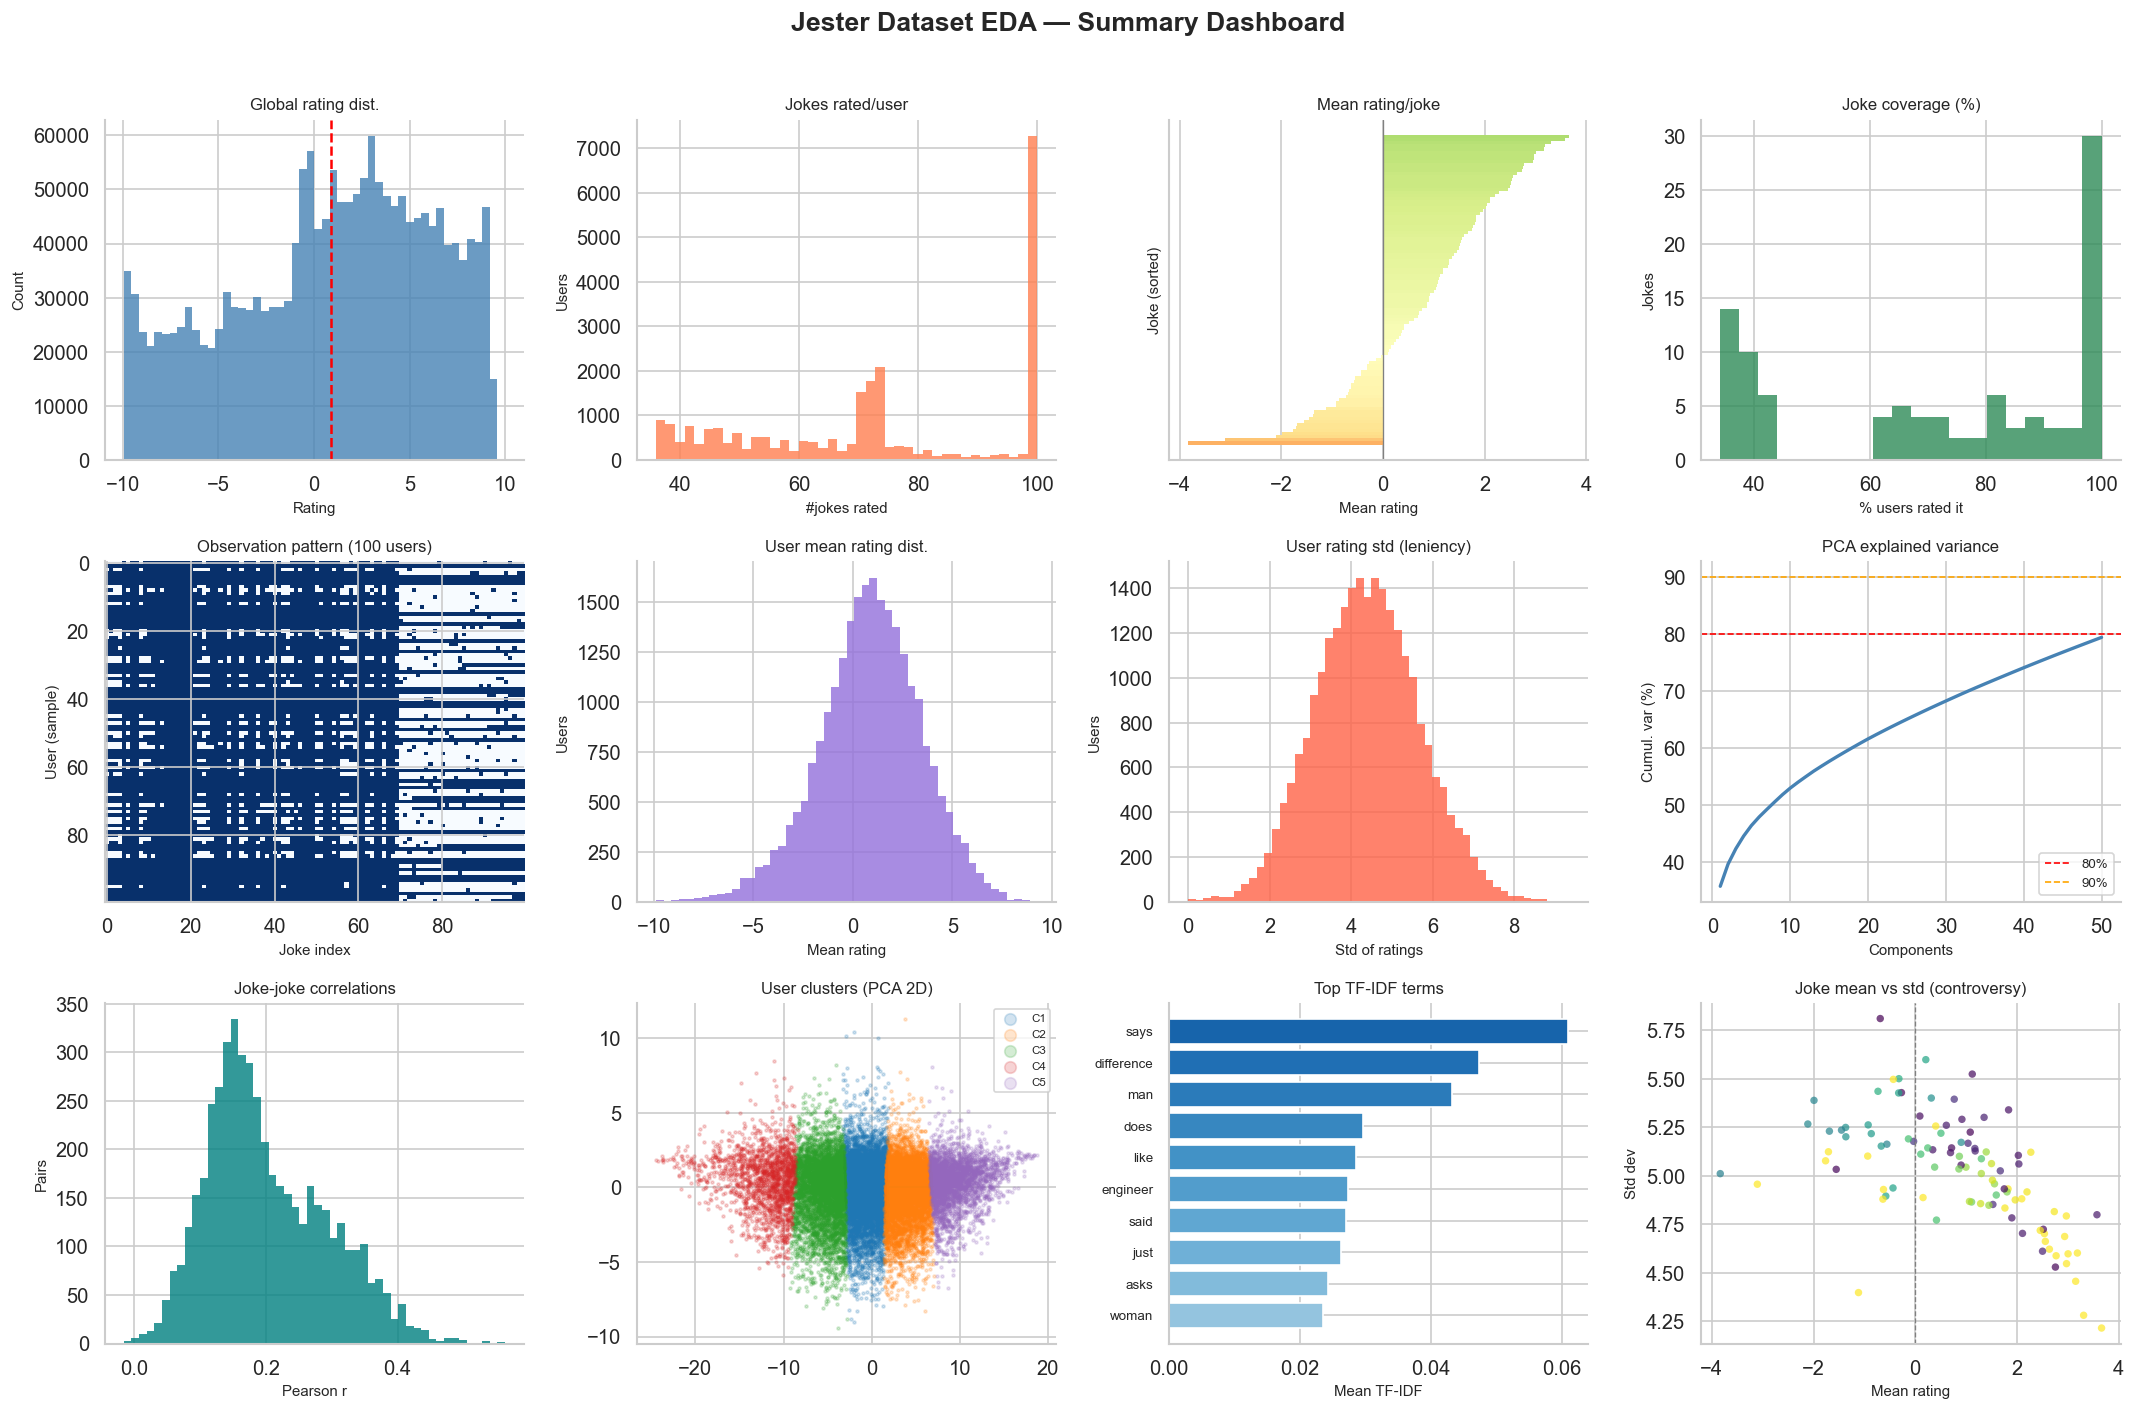

Dashboard saved as jester_eda_dashboard.png


In [34]:
# ── Final EDA summary dashboard ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Jester Dataset EDA — Summary Dashboard', fontsize=16, fontweight='bold', y=0.98)

# 1. Global rating histogram
ax1 = fig.add_subplot(3, 4, 1)
ax1.hist(all_ratings, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax1.axvline(np.mean(all_ratings), color='red', lw=1.5, linestyle='--')
ax1.set_title('Global rating dist.', fontsize=10)
ax1.set_xlabel('Rating', fontsize=9); ax1.set_ylabel('Count', fontsize=9)

# 2. Ratings per user
ax2 = fig.add_subplot(3, 4, 2)
ax2.hist(user_stats['n_rated'], bins=40, color='coral', edgecolor='none', alpha=0.8)
ax2.set_title('Jokes rated/user', fontsize=10)
ax2.set_xlabel('#jokes rated', fontsize=9); ax2.set_ylabel('Users', fontsize=9)

# 3. Mean rating per joke
ax3 = fig.add_subplot(3, 4, 3)
sorted_means = joke_stats['mean'].sort_values()
ax3.barh(range(100), sorted_means.values,
          color=plt.cm.RdYlGn((sorted_means.values + 10) / 20), height=1, edgecolor='none')
ax3.axvline(0, color='gray', lw=0.8)
ax3.set_title('Mean rating/joke', fontsize=10)
ax3.set_xlabel('Mean rating', fontsize=9); ax3.set_ylabel('Joke (sorted)', fontsize=9)
ax3.set_yticks([])

# 4. Joke coverage
ax4 = fig.add_subplot(3, 4, 4)
ax4.hist(joke_rated_pct.values, bins=20, color='seagreen', edgecolor='none', alpha=0.8)
ax4.set_title('Joke coverage (%)', fontsize=10)
ax4.set_xlabel('% users rated it', fontsize=9); ax4.set_ylabel('Jokes', fontsize=9)

# 5. Sparsity pattern (mini)
ax5 = fig.add_subplot(3, 4, 5)
mini_sample = ratings.sample(100, random_state=SEED)
ax5.imshow(mini_sample.notna().astype(int).values,
            aspect='auto', cmap='Blues', interpolation='nearest')
ax5.set_title('Observation pattern (100 users)', fontsize=10)
ax5.set_xlabel('Joke index', fontsize=9); ax5.set_ylabel('User (sample)', fontsize=9)

# 6. User mean rating dist
ax6 = fig.add_subplot(3, 4, 6)
ax6.hist(user_stats['mean_rating'].dropna(), bins=50, color='mediumpurple', edgecolor='none', alpha=0.8)
ax6.set_title('User mean rating dist.', fontsize=10)
ax6.set_xlabel('Mean rating', fontsize=9); ax6.set_ylabel('Users', fontsize=9)

# 7. User std dist
ax7 = fig.add_subplot(3, 4, 7)
ax7.hist(user_stats['std_rating'].dropna(), bins=50, color='tomato', edgecolor='none', alpha=0.8)
ax7.set_title('User rating std (leniency)', fontsize=10)
ax7.set_xlabel('Std of ratings', fontsize=9); ax7.set_ylabel('Users', fontsize=9)

# 8. PCA variance
ax8 = fig.add_subplot(3, 4, 8)
ax8.plot(range(1, 51), cum_var, lw=2, color='steelblue')
ax8.axhline(80, color='red', lw=1, linestyle='--', label='80%')
ax8.axhline(90, color='orange', lw=1, linestyle='--', label='90%')
ax8.set_title('PCA explained variance', fontsize=10)
ax8.set_xlabel('Components', fontsize=9); ax8.set_ylabel('Cumul. var (%)', fontsize=9)
ax8.legend(fontsize=8)

# 9. Joke corr distribution
ax9 = fig.add_subplot(3, 4, 9)
corr_off_diag = joke_corr.values[np.triu_indices(100, k=1)]
ax9.hist(corr_off_diag, bins=50, color='teal', edgecolor='none', alpha=0.8)
ax9.set_title('Joke-joke correlations', fontsize=10)
ax9.set_xlabel('Pearson r', fontsize=9); ax9.set_ylabel('Pairs', fontsize=9)

# 10. Cluster scatter
ax10 = fig.add_subplot(3, 4, 10)
for k in range(K_BEST):
    m = cluster_labels == k
    ax10.scatter(X_2d[m, 0], X_2d[m, 1], s=3, alpha=0.2, color=palette[k], label=f'C{k+1}')
ax10.set_title('User clusters (PCA 2D)', fontsize=10)
ax10.legend(markerscale=4, fontsize=7, loc='best')

# 11. Top 10 TF-IDF terms
ax11 = fig.add_subplot(3, 4, 11)
top10 = feature_names[top_indices[:10]]
vals10 = mean_tfidf[top_indices[:10]]
ax11.barh(range(10), vals10[::-1], color=plt.cm.Blues(np.linspace(0.4, 0.8, 10)))
ax11.set_yticks(range(10)); ax11.set_yticklabels(top10[::-1], fontsize=8)
ax11.set_title('Top TF-IDF terms', fontsize=10)
ax11.set_xlabel('Mean TF-IDF', fontsize=9)

# 12. Mean vs Std scatter (jokes)
ax12 = fig.add_subplot(3, 4, 12)
ax12.scatter(joke_stats['mean'], joke_stats['std'], s=20, alpha=0.7,
              c=joke_stats['n_rated'], cmap='viridis', edgecolors='none')
ax12.axvline(0, color='gray', lw=0.8, linestyle='--')
ax12.set_title('Joke mean vs std (controversy)', fontsize=10)
ax12.set_xlabel('Mean rating', fontsize=9); ax12.set_ylabel('Std dev', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('jester_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as jester_eda_dashboard.png')

In [ ]:
# ── Save preprocessed artefacts for Phase 3 modelling ─────────────────────────
import os, pickle

os.makedirs('data', exist_ok=True)

# 1. Save ratings (NaN = missing)
ratings.to_parquet('data/ratings_clean.parquet')

# 2. Save user and joke stats
user_stats.to_parquet('data/user_stats.parquet')
joke_stats.to_parquet('data/joke_stats.parquet')

# 3. Save TF-IDF matrix
import scipy.sparse as sp
sp.save_npz('data/tfidf_jokes.npz', X_tfidf)

# 4. Save cluster labels
np.save('data/user_cluster_labels.npy', cluster_labels)

# 5. Save PCA-reduced features
np.save('data/user_pca_features.npy', X_pca)

print('Artefacts saved to ./data/')
print('  ratings_clean.parquet       — cleaned NaN matrix')
print('  user_stats.parquet          — per-user statistics')
print('  joke_stats.parquet          — per-joke statistics')
print('  tfidf_jokes.npz             — sparse TF-IDF features')
print('  user_cluster_labels.npy     — K-Means cluster assignments')
print('  user_pca_features.npy       — 50-dim PCA user vectors')

Artefacts saved to ./data/
  ratings_clean.parquet       — cleaned NaN matrix
  user_stats.parquet          — per-user statistics
  joke_stats.parquet          — per-joke statistics
  tfidf_jokes.npz             — sparse TF-IDF features
  user_cluster_labels.npy     — K-Means cluster assignments
  user_pca_features.npy       — 50-dim PCA user vectors

EDA complete. Ready for Phase 3 (Preprocessing & Feature Engineering).
